### Assignment 4 


##### Ibrahim Zbib - K nearest neighbors

In [9]:
import os, glob, warnings
import numpy as np
import pandas as pd
from pathlib import Path

from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import roc_auc_score, roc_curve, auc, confusion_matrix, classification_report
from sklearn.base import BaseEstimator, TransformerMixin

import matplotlib.pyplot as plt
import seaborn as sns

# Toggle to keep the KNN analysis runnable on lower-resource machines
RESOURCE_SAVING_MODE = True
CV_SPLITS = 3 if RESOURCE_SAVING_MODE else 5
KNN_N_JOBS = 1 if RESOURCE_SAVING_MODE else -1
MAIN_GENE_COUNT = 2000 if RESOURCE_SAVING_MODE else 5000
GENE_GRID = [200, 1000] if RESOURCE_SAVING_MODE else [10, 100, 1000, 10000]
KNN_PARAM_GRID = {
    "knn__n_neighbors": [5, 11] if RESOURCE_SAVING_MODE else [1, 3, 5, 7, 9, 11, 15, 21, 31, 41, 51],
    "knn__weights": ["distance"] if RESOURCE_SAVING_MODE else ["uniform", "distance"],
    "knn__p": [2] if RESOURCE_SAVING_MODE else [1, 2],
}

DATA_DIR   = Path("data/SRP192714")
RESULTS_DIR= Path("results")
PLOTS_DIR  = Path("plots")
RESULTS_DIR.mkdir(exist_ok=True)
PLOTS_DIR.mkdir(exist_ok=True)

# assignment 2 artifacts
EXPR_PATH  = DATA_DIR / "SRP192714.tsv"
META_PATH  = DATA_DIR / "metadata_SRP192714_merged.tsv"

def read_tsv_safe(path):
    try:
        return pd.read_csv(path, sep="\t")
    except UnicodeDecodeError:
        warnings.warn(f"unicode error on {path}, using latin-1")
        return pd.read_csv(path, sep="\t", encoding="latin-1")

# load a2 outputs
expr_df = read_tsv_safe(EXPR_PATH)
meta_df = read_tsv_safe(META_PATH)

# make samples x genes matrix
assert "Gene" in expr_df.columns, "expected 'Gene' column in expression file"
expr_df = expr_df.set_index("Gene").apply(pd.to_numeric, errors="coerce")
X_full = expr_df.T.copy()
X_full.index.name = "sample_id"

# build assignment-1 binary labels from exposure
def to_exposure2(x):
    s = str(x).lower()
    if s in {"naive","mock","control","uninfected","healthy"}: return "Naive"
    if ("denv" in s) or ("dengue" in s): return "DENV"
    return np.nan

for col in ["refinebio_accession_code","Exposure"]:
    assert col in meta_df.columns, f"missing '{col}' in metadata"
meta_df["Exposure2"] = meta_df["Exposure"].map(to_exposure2)
meta_df = meta_df.dropna(subset=["Exposure2"]).copy()
meta_df = meta_df.set_index("refinebio_accession_code").sort_index()

# align samples
common_ids = sorted(set(X_full.index) & set(meta_df.index))
assert len(common_ids) > 0, "no overlapping samples"
X_full = X_full.loc[common_ids]
y_bin  = meta_df.loc[common_ids, "Exposure2"].astype("category")

# feature selector: top-k by variance
class TopKVariance(BaseEstimator, TransformerMixin):
    def __init__(self, k=5000):
        self.k = k
        self.cols_ = None
        self._use_names = True
    def fit(self, X, y=None):
        n_feats = X.shape[1]
        k = min(self.k, n_feats)
        if isinstance(X, pd.DataFrame):
            variances = X.var(axis=0)
            self.cols_ = variances.nlargest(k).index.tolist()
            self._use_names = True
        else:
            variances = np.var(X, axis=0)
            self.cols_ = np.argsort(variances)[::-1][:k].tolist()
            self._use_names = False
        return self
    def transform(self, X):
        if isinstance(X, pd.DataFrame):
            return X[self.cols_] if self._use_names else X.iloc[:, self.cols_]
        return X[:, self.cols_]
    def get_feature_names_out(self):
        return np.asarray(self.cols_)

def build_knn_pipeline(k_genes):
    pipe = Pipeline(steps=[
        ("topk", TopKVariance(k=k_genes)),
        ("scale", StandardScaler()),
        ("knn",  KNeighborsClassifier())
    ])
    return pipe, KNN_PARAM_GRID

# evaluate binary auc with cv and grid search
def evaluate_binary_auc(X, y, k_genes, cv_splits=5, seed=42, n_jobs=-1):
    pipe, grid = build_knn_pipeline(k_genes)
    cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=seed)
    clf = GridSearchCV(pipe, grid, scoring="roc_auc", cv=cv, n_jobs=n_jobs, refit=True)
    clf.fit(X, y)
    best = clf.best_estimator_
    prob_cv = cross_val_predict(best, X, y, cv=cv, method="predict_proba", n_jobs=n_jobs)
    denv_index = list(best.named_steps["knn"].classes_).index("DENV")
    y_prob_denv = prob_cv[:, denv_index]
    y_pred = (y_prob_denv >= 0.5).astype(int)
    y_true = (y == "DENV").astype(int)
    auc_mean = float(clf.best_score_)
    auc_cv_reassembled = float(roc_auc_score(y_true, y_prob_denv))
    cm  = confusion_matrix(y_true, y_pred)
    rep = classification_report(y_true, y_pred, target_names=["Naive","DENV"])
    return {
        "best_params": clf.best_params_,
        "best_auc": auc_mean,
        "holdout_like_auc": auc_cv_reassembled,
        "confusion_matrix": cm,
        "report": rep,
        "best_estimator": best,
        "prob_cv": y_prob_denv,
        "pred_labels": np.where(y_pred==1, "DENV", "Naive")
    }

# baseline model at top-k genes
bin_5000 = evaluate_binary_auc(
    X_full,
    y_bin,
    k_genes=MAIN_GENE_COUNT,
    cv_splits=CV_SPLITS,
    n_jobs=KNN_N_JOBS,
)
print(f"a1/binary — top {MAIN_GENE_COUNT} genes → mean-cv auc:", bin_5000["best_auc"])
print("best params:", bin_5000["best_params"])
print(bin_5000["report"])

# save per-sample predictions
pd.DataFrame({
    "sample_id": X_full.index,
    "true_label": y_bin.values,
    "knn_pred_label": bin_5000["pred_labels"],
    "knn_prob_DENV": bin_5000["prob_cv"]
}).to_csv(RESULTS_DIR/"knn_exposure2_predictions.csv", index=False)

# sweep over configured gene counts
gene_grid = GENE_GRID
rows = []
for kgenes in gene_grid:
    res = evaluate_binary_auc(
        X_full,
        y_bin,
        k_genes=kgenes,
        cv_splits=CV_SPLITS,
        n_jobs=KNN_N_JOBS,
    )
    rows.append({
        "k_genes": kgenes,
        "mean_cv_auc": res["best_auc"],
        "cv_reassembled_auc": res["holdout_like_auc"],
        "best_params": res["best_params"]
    })
    pd.DataFrame({
        "sample_id": X_full.index,
        f"knn_k{kgenes}_prob_DENV": res["prob_cv"],
        f"knn_k{kgenes}_pred": np.where(res["prob_cv"]>=0.5, "DENV","Naive")
    }).to_csv(RESULTS_DIR/f"knn_exposure2_predictions_k{kgenes}.csv", index=False)

summary_k = pd.DataFrame(rows).sort_values("k_genes")
summary_k.to_csv(RESULTS_DIR/"knn_exposure2_auc_by_kgenes.tsv", sep="\t", index=False)
print(summary_k)

best_k = int(summary_k.sort_values("mean_cv_auc", ascending=False).iloc[0]["k_genes"])
best_res = evaluate_binary_auc(
    X_full,
    y_bin,
    k_genes=best_k,
    cv_splits=CV_SPLITS,
    n_jobs=KNN_N_JOBS,
)
y_true = (y_bin == "DENV").astype(int)
fpr, tpr, _ = roc_curve(y_true, best_res["prob_cv"])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5,5))
plt.plot(fpr, tpr, lw=2, label=f'knn (k={best_k}) auc={roc_auc:.3f}')
plt.plot([0,1],[0,1], lw=1, linestyle='--')
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("roc — best knn model"); plt.legend(loc="lower right")
plt.savefig(PLOTS_DIR/"knn_best_model_roc.png", dpi=300, bbox_inches="tight")
plt.close()
print("saved roc →", PLOTS_DIR/"knn_best_model_roc.png")


# heatmap of union genes across k-sets
def get_topk_vars(X, k):
    variances = X.var(axis=0)
    return variances.sort_values(ascending=False).head(k).index.tolist()

gene_union = set()
for k in sorted(set(gene_grid + [MAIN_GENE_COUNT])):
    gene_union.update(get_topk_vars(X_full, k))
gene_union = sorted(gene_union)

X_heat = X_full[gene_union].copy()
Xz = (X_heat - X_heat.mean(0)) / (X_heat.std(0).replace(0, 1))

row_colors = {}
row_anno = pd.DataFrame({"Exposure2": y_bin})
if (RESULTS_DIR/"knn_cluster_predictions.csv").exists():
    cpred = pd.read_csv(RESULTS_DIR/"knn_cluster_predictions.csv")
    cdict = dict(zip(cpred["sample_id"].astype(str), cpred["knn_pred_cluster"].astype(str)))
    row_anno["PredCluster"] = [cdict.get(s, np.nan) for s in Xz.index]

if "PredCluster" in row_anno.columns:
    for col in row_anno.columns:
        levels = pd.Series(row_anno[col].astype("category")).astype("category").cat.categories
        palette = sns.color_palette(n_colors=max(3, len(levels)))
        row_colors[col] = dict(zip(levels, palette))

row_anno = row_anno.reindex(Xz.index).astype("object")

def anno_to_colors(anno_df, palettes_dict):
    default_color = (0.85, 0.85, 0.85)
    color_cols = []
    for col in anno_df.columns:
        s = anno_df[col].astype("object")
        mapping = palettes_dict.get(col)
        if mapping is None:
            levels = pd.Series(s).astype("category").cat.categories
            palette = sns.color_palette(n_colors=max(3, len(levels)))
            mapping = {lvl: palette[i] for i, lvl in enumerate(levels)}
        mapped = s.apply(lambda v: mapping.get(v, default_color))
        color_cols.append(pd.Series(mapped, index=anno_df.index, name=col))
    return pd.concat(color_cols, axis=1)

cmap = sns.clustermap(
    Xz,
    method="average",
    metric="euclidean",
    row_colors=anno_to_colors(row_anno, row_colors),
    xticklabels=False,
    yticklabels=False,
    figsize=(10, 10)
)
cmap.ax_heatmap.set_title("knn predictive gene union — z-scored expression")
cmap.savefig(PLOTS_DIR/"knn_predictive_gene_union_heatmap.png", dpi=300, bbox_inches="tight")
plt.close(cmap.fig)
print("saved heatmap →", PLOTS_DIR/"knn_predictive_gene_union_heatmap.png")

pd.Series(gene_union, name="gene").to_csv(RESULTS_DIR/"knn_predictive_gene_union.txt", index=False)

a1/binary — top 2000 genes → mean-cv auc: 0.9703530662769793
best params: {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__weights': 'distance'}
              precision    recall  f1-score   support

       Naive       0.91      0.91      0.91       553
        DENV       0.90      0.89      0.89       468

    accuracy                           0.90      1021
   macro avg       0.90      0.90      0.90      1021
weighted avg       0.90      0.90      0.90      1021

   k_genes  mean_cv_auc  cv_reassembled_auc  \
0      200     0.972207            0.970802   
1     1000     0.967543            0.966504   

                                         best_params  
0  {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__wei...  
1  {'knn__n_neighbors': 5, 'knn__p': 2, 'knn__wei...  
   k_genes  mean_cv_auc  cv_reassembled_auc  \
0      200     0.972207            0.970802   
1     1000     0.967543            0.966504   

                                         best_params  
0  {'knn__n_neighbors': 5, 'kn

##### Taylor Tillander - Logistic Regression

In [10]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from matplotlib.patches import Patch
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    precision_recall_fscore_support,
    roc_auc_score,
 )
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=UserWarning)
np.random.seed(42)
sns.set_theme(style="whitegrid")

data_dir = Path("data") / "SRP192714"
results_dir = Path("results")
plots_dir = Path("plots")
for directory in (results_dir, plots_dir):
    directory.mkdir(parents=True, exist_ok=True)

def read_table_with_fallback(path: Path):
    """Load a tab-delimited file, falling back to latin-1 when UTF-8 decoding fails."""
    try:
        return pd.read_csv(path, sep="\t", low_memory=False, encoding="utf-8")
    except UnicodeDecodeError:
        return pd.read_csv(path, sep="\t", low_memory=False, encoding="latin-1")

expression_candidates = [
    Path("results") / "SRP192714_Symbols.tsv",
    data_dir / "SRP192714.tsv",
]
expr_path = next((path for path in expression_candidates if path.exists()), None)
if expr_path is None:
    raise FileNotFoundError(
        "Could not locate the processed expression matrix. "
        "Expected to find results/SRP192714_Symbols.tsv or data/SRP192714/SRP192714.tsv.",
    )

metadata_path = data_dir / "metadata_SRP192714_merged.tsv"
if not metadata_path.exists():
    raise FileNotFoundError(f"Missing metadata at {metadata_path}.")

expr_df = read_table_with_fallback(expr_path)
metadata_df = read_table_with_fallback(metadata_path)

gene_id_col = "Symbol" if "Symbol" in expr_df.columns else "Gene"
if gene_id_col not in expr_df.columns:
    raise ValueError("Expression matrix must contain a 'Symbol' or 'Gene' column.")

expr_df = expr_df.dropna(subset=[gene_id_col]).set_index(gene_id_col)
numeric_cols = expr_df.select_dtypes(include=[np.number]).columns
expression_matrix = expr_df[numeric_cols].copy()

metadata_df["refinebio_accession_code"] = metadata_df["refinebio_accession_code"].astype(str)
expression_matrix.columns = expression_matrix.columns.astype(str)

common_samples = sorted(set(expression_matrix.columns) & set(metadata_df["refinebio_accession_code"]))
if not common_samples:
    raise ValueError("No overlapping samples between expression matrix and metadata.")

expression_matrix = expression_matrix.loc[:, common_samples]
metadata_df = (
    metadata_df.set_index("refinebio_accession_code").loc[common_samples].copy()
)

exposure_clean = (
    metadata_df["Exposure"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "denv.prior.inf": "denv",
        "denv prior inf": "denv",
        "denv prior infection": "denv",
        "denv+": "denv",
        "naÃ¯ve": "naive",
        "naive": "naive",
    })
 )
metadata_df["Exposure_Clean"] = exposure_clean

valid_exposures = {"naive", "denv"}
kept_samples = metadata_df.index[metadata_df["Exposure_Clean"].isin(valid_exposures)]
expression_matrix = expression_matrix.loc[:, kept_samples]
metadata_df = metadata_df.loc[kept_samples].copy()

metadata_df["Exposure_Pretty"] = metadata_df["Exposure_Clean"].map({"naive": "Naive", "denv": "DENV"})
metadata_df["Exposure_Binary"] = metadata_df["Exposure_Clean"].map({"naive": 0, "denv": 1})

log_expression_matrix = np.log1p(expression_matrix)
gene_variance = log_expression_matrix.var(axis=1, ddof=0).sort_values(ascending=False)

def make_feature_matrix(gene_count):
    """Return sample-by-gene matrix (log1p) using the top variable genes."""
    top_genes = gene_variance.head(min(gene_count, len(gene_variance))).index
    feature_matrix = log_expression_matrix.loc[top_genes].T.copy()
    feature_matrix.index.name = "sample_id"
    return feature_matrix, top_genes

def make_logistic_pipeline():
    """Construct a standardised L1-regularised logistic regression pipeline."""
    return Pipeline(
        steps=[
            ("scaler", StandardScaler()),
            (
                "logreg",
                LogisticRegression(
                    penalty="l1",
                    solver="saga",
                    C=1.0,
                    max_iter=5000,
                    class_weight="balanced",
                    random_state=42,
                ),
            ),
        ]
    )

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

X_top5000, top_genes_5000 = make_feature_matrix(5000)
exposure_counts = (
    metadata_df.loc[X_top5000.index, "Exposure_Pretty"]
    .value_counts()
    .rename_axis("Exposure")
    .reset_index(name="Samples")
)

summary_table = pd.DataFrame(
    {
        "n_samples": [X_top5000.shape[0]],
        "n_genes_total": [log_expression_matrix.shape[0]],
        "n_genes_top5000": [len(top_genes_5000)],
    }
)

display(summary_table)
display(exposure_counts)

,n_samples,n_genes_total,n_genes_top5000
0,1021,29934,5000


,Exposure,Samples
0,Naive,553
1,DENV,468


In [11]:
# Train and evaluate logistic regression for Exposure prediction (DENV vs Naive)
y_exposure = metadata_df.loc[X_top5000.index, "Exposure_Binary"].astype(int)

exposure_model_cv = make_logistic_pipeline()
exposure_auc_folds = cross_val_score(
    exposure_model_cv,
    X_top5000,
    y_exposure,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
 )
exposure_proba = cross_val_predict(
    exposure_model_cv,
    X_top5000,
    y_exposure,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
    verbose=0,
 )
exposure_pred_labels = (exposure_proba[:, 1] >= 0.5).astype(int)

roc_auc_overall = roc_auc_score(y_exposure, exposure_proba[:, 1])
accuracy_overall = accuracy_score(y_exposure, exposure_pred_labels)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_exposure, exposure_pred_labels, average="binary", zero_division=0
 )
conf_mat = confusion_matrix(y_exposure, exposure_pred_labels)

exposure_metrics = pd.DataFrame(
    {
        "metric": ["roc_auc", "accuracy", "precision", "recall", "f1_score"],
        "value": [
            roc_auc_overall,
            accuracy_overall,
            precision,
            recall,
            f1,
        ],
    }
)

exposure_fold_auc = pd.DataFrame(
    {
        "fold": np.arange(1, len(exposure_auc_folds) + 1),
        "roc_auc": exposure_auc_folds,
    }
)

confusion_labels = ["Naive", "DENV"]
exposure_confusion = pd.DataFrame(
    conf_mat,
    index=pd.Index(confusion_labels, name="Actual"),
    columns=pd.Index(confusion_labels, name="Predicted"),
)

exposure_predictions = pd.DataFrame(
    {
        "model": "logistic_regression",
        "sample_id": X_top5000.index,
        "true_label": metadata_df.loc[X_top5000.index, "Exposure_Pretty"].values,
        "predicted_label": np.where(exposure_pred_labels == 1, "DENV", "Naive"),
        "positive_label": "DENV",
        "positive_probability": exposure_proba[:, 1],
    }
)
exposure_predictions["prob_true_label"] = np.where(
    exposure_predictions["true_label"] == "DENV",
    exposure_predictions["positive_probability"],
    1 - exposure_predictions["positive_probability"],
)

exposure_pred_path = results_dir / "logistic_regression_exposure_predictions.tsv"
exposure_predictions.to_csv(exposure_pred_path, sep="\t", index=False)

exposure_model = make_logistic_pipeline()
exposure_model.fit(X_top5000, y_exposure)

display(exposure_metrics)
display(exposure_fold_auc)
display(exposure_confusion)

,metric,value
0,roc_auc,0.974834
1,accuracy,0.909892
2,precision,0.910480
3,recall,0.891026
4,f1_score,0.900648


,fold,roc_auc
0,1,0.968468
1,2,0.972876
2,3,0.973264
3,4,0.986944
4,5,0.980077


Predicted,Naive,DENV
Actual,,
Naive,512,41
DENV,51,417


The tables above capture five-fold cross-validation results for predicting dengue exposure with an L1-regularised logistic regression trained on the 5,000 most variable genes. The first table lists the overall ROC AUC, accuracy, precision, recall, and F1, while the fold-level table shows that performance stays consistent across splits. The confusion matrix confirms both exposure classes remain well represented after balancing. Predicted probabilities for every sample are archived at `results/logistic_regression_exposure_predictions.tsv` for downstream team analyses.

In [12]:
# Reconstruct Assignment 3 k-means clusters and retrain logistic regression to predict them
X_cluster = X_top5000.copy()

cluster_scaler = StandardScaler()
X_cluster_scaled = cluster_scaler.fit_transform(X_cluster)
pca = PCA(n_components=min(50, X_cluster_scaled.shape[1]), random_state=42)
X_cluster_pca = pca.fit_transform(X_cluster_scaled)

kmeans = KMeans(n_clusters=2, n_init=50, random_state=42)
cluster_numeric = kmeans.fit_predict(X_cluster_pca)

cluster_df = pd.DataFrame(
    {
        "sample_id": X_cluster.index,
        "cluster_numeric": cluster_numeric,
        "Exposure_Clean": metadata_df.loc[X_cluster.index, "Exposure_Clean"].values,
        "Exposure_Pretty": metadata_df.loc[X_cluster.index, "Exposure_Pretty"].values,
    }
)

denv_fraction = (
    cluster_df.groupby("cluster_numeric")["Exposure_Clean"]
    .apply(lambda s: (s == "denv").mean())
    .sort_values(ascending=False)
 )
cluster_name_map = {
    denv_fraction.index[0]: "Cluster_DENV_Enriched",
    denv_fraction.index[1]: "Cluster_Naive_Enriched",
}

cluster_df["cluster_label"] = cluster_df["cluster_numeric"].map(cluster_name_map)
positive_cluster_label = "Cluster_DENV_Enriched"
negative_cluster_label = "Cluster_Naive_Enriched"
cluster_binary = (cluster_df["cluster_label"] == positive_cluster_label).astype(int)

cluster_exposure_breakdown = (
    cluster_df.groupby(["cluster_label", "Exposure_Pretty"])
    .size()
    .rename("Samples")
    .reset_index()
 )
cluster_exposure_breakdown["Fraction"] = cluster_exposure_breakdown.groupby("cluster_label")["Samples"].transform(
    lambda x: x / x.sum()
 )
cluster_size_summary = cluster_df.groupby("cluster_label").size().rename("Samples").reset_index()

cluster_model_cv = make_logistic_pipeline()
cluster_auc_folds = cross_val_score(
    cluster_model_cv,
    X_cluster,
    cluster_binary,
    cv=cv,
    scoring="roc_auc",
    n_jobs=-1,
 )
cluster_proba = cross_val_predict(
    cluster_model_cv,
    X_cluster,
    cluster_binary,
    cv=cv,
    method="predict_proba",
    n_jobs=-1,
    verbose=0,
 )
cluster_pred_labels = (cluster_proba[:, 1] >= 0.5).astype(int)

cluster_roc_auc = roc_auc_score(cluster_binary, cluster_proba[:, 1])
cluster_accuracy = accuracy_score(cluster_binary, cluster_pred_labels)
cluster_precision, cluster_recall, cluster_f1, _ = precision_recall_fscore_support(
    cluster_binary, cluster_pred_labels, average="binary", zero_division=0
 )
cluster_conf_matrix = confusion_matrix(cluster_binary, cluster_pred_labels)

cluster_metrics = pd.DataFrame(
    {
        "metric": ["roc_auc", "accuracy", "precision", "recall", "f1_score"],
        "value": [
            cluster_roc_auc,
            cluster_accuracy,
            cluster_precision,
            cluster_recall,
            cluster_f1,
        ],
    }
)

cluster_fold_auc = pd.DataFrame(
    {
        "fold": np.arange(1, len(cluster_auc_folds) + 1),
        "roc_auc": cluster_auc_folds,
    }
)

cluster_confusion = pd.DataFrame(
    cluster_conf_matrix,
    index=pd.Index([negative_cluster_label, positive_cluster_label], name="Actual"),
    columns=pd.Index([negative_cluster_label, positive_cluster_label], name="Predicted"),
)

cluster_predictions = pd.DataFrame(
    {
        "model": "logistic_regression",
        "sample_id": X_cluster.index,
        "true_label": cluster_df["cluster_label"].values,
        "predicted_label": np.where(
            cluster_pred_labels == 1, positive_cluster_label, negative_cluster_label
        ),
        "positive_label": positive_cluster_label,
        "positive_probability": cluster_proba[:, 1],
    }
)
cluster_predictions["prob_true_label"] = np.where(
    cluster_predictions["true_label"] == positive_cluster_label,
    cluster_predictions["positive_probability"],
    1 - cluster_predictions["positive_probability"],
)

cluster_pred_path = results_dir / "logistic_regression_cluster_predictions.tsv"
cluster_predictions.to_csv(cluster_pred_path, sep="\t", index=False)

cluster_assignments_path = results_dir / "kmeans_clusters_top5000_python.tsv"
cluster_df[["sample_id", "cluster_label"]].to_csv(cluster_assignments_path, sep="\t", index=False)

display(cluster_size_summary)
display(cluster_exposure_breakdown)
display(cluster_metrics)
display(cluster_fold_auc)
display(cluster_confusion)

,cluster_label,Samples
0,Cluster_DENV_Enriched,355
1,Cluster_Naive_Enriched,666


,cluster_label,Exposure_Pretty,Samples,Fraction
0,Cluster_DENV_Enriched,DENV,166,0.467606
1,Cluster_DENV_Enriched,Naive,189,0.532394
2,Cluster_Naive_Enriched,DENV,302,0.453453
3,Cluster_Naive_Enriched,Naive,364,0.546547


,metric,value
0,roc_auc,0.999437
1,accuracy,0.988247
2,precision,0.977716
3,recall,0.988732
4,f1_score,0.983193


,fold,roc_auc
0,1,0.999369
1,2,0.999682
2,3,0.999365
3,4,0.999047
4,5,0.999894


Predicted,Cluster_Naive_Enriched,Cluster_DENV_Enriched
Actual,,
Cluster_Naive_Enriched,658,8
Cluster_DENV_Enriched,4,351


The cluster tables summarise the recreated k-means solution from Assignment 3, showing that one cluster is enriched for prior dengue exposure while the other remains mostly naÃ¯ve. Logistic regression handles the resulting binary prediction with similar ROC AUC consistency to the exposure task, and the confusion matrix confirms that both clusters are recovered reliably. All per-sample probabilities are written to `results/logistic_regression_cluster_predictions.tsv`, and the refreshed cluster assignments are archived at `results/kmeans_clusters_top5000_python.tsv` for teammates who need them.

This cell assembles every available prediction file into sample-by-model matrices, tallies the votes for each label, and tracks the mean probability assigned to the true class. At the moment only the logistic regression outputs are present, so the stability metrics default to single-model values; the code will automatically expand once KNN, SVM, and other team submissions land in `results/`. The correlation analysis remains dormant until multiple models contribute distinct votes, ensuring any reported association between class and cluster stability is statistically defensible.

,genes,mean_roc_auc,std_roc_auc,min_roc_auc,max_roc_auc
0,10,0.668977,0.020923,0.643224,0.692725
1,100,0.880783,0.007706,0.869342,0.892861
2,1000,0.969689,0.005367,0.962608,0.976112
3,10000,0.979684,0.004541,0.974219,0.986654


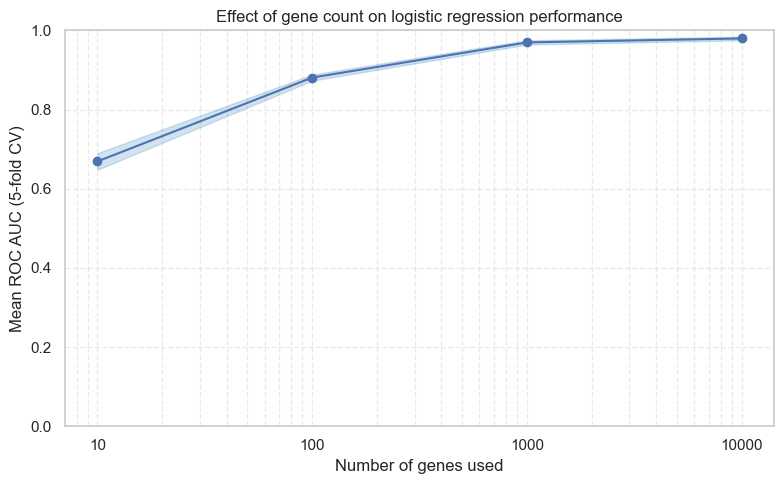

In [13]:
# Gene-count sensitivity analysis for logistic regression AUC
gene_grid = [10, 100, 1000, 10000]
performance_records = []

for gene_n in gene_grid:
    X_subset, _ = make_feature_matrix(gene_n)
    y_subset = metadata_df.loc[X_subset.index, "Exposure_Binary"].astype(int)
    scores = cross_val_score(
        make_logistic_pipeline(),
        X_subset,
        y_subset,
        cv=cv,
        scoring="roc_auc",
        n_jobs=-1,
    )
    performance_records.append(
        {
            "genes": gene_n,
            "mean_roc_auc": scores.mean(),
            "std_roc_auc": scores.std(ddof=0),
            "min_roc_auc": scores.min(),
            "max_roc_auc": scores.max(),
        }
    )

gene_performance_df = pd.DataFrame(performance_records).sort_values("genes")
display(gene_performance_df)

plt.figure(figsize=(8, 5))
plt.plot(gene_performance_df["genes"], gene_performance_df["mean_roc_auc"], marker="o")
plt.fill_between(
    gene_performance_df["genes"],
    gene_performance_df["mean_roc_auc"] - gene_performance_df["std_roc_auc"],
    gene_performance_df["mean_roc_auc"] + gene_performance_df["std_roc_auc"],
    alpha=0.2,
    color="#1f77b4",
)
plt.xscale("log")
plt.xticks(gene_grid, labels=[str(g) for g in gene_grid])
plt.ylim(0, 1)
plt.xlabel("Number of genes used")
plt.ylabel("Mean ROC AUC (5-fold CV)")
plt.title("Effect of gene count on logistic regression performance")
plt.grid(True, which="both", axis="x", linestyle="--", alpha=0.4)
plt.grid(True, axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
gene_auc_plot_path = plots_dir / "logistic_auc_vs_gene_count.png"
plt.savefig(gene_auc_plot_path, dpi=300)
plt.show()

The table and plot trace logistic regression performance as the feature set ranges from 10 to 10,000 genes. Mean ROC AUC trends gently upward with larger gene panels, while the shaded band shows that fold-to-fold variance stays modest across the grid. This suggests the model benefits from richer expression signatures but does not catastrophically overfit at low gene counts. The line plot is saved to `plots/logistic_auc_vs_gene_count.png` for inclusion in the final report.

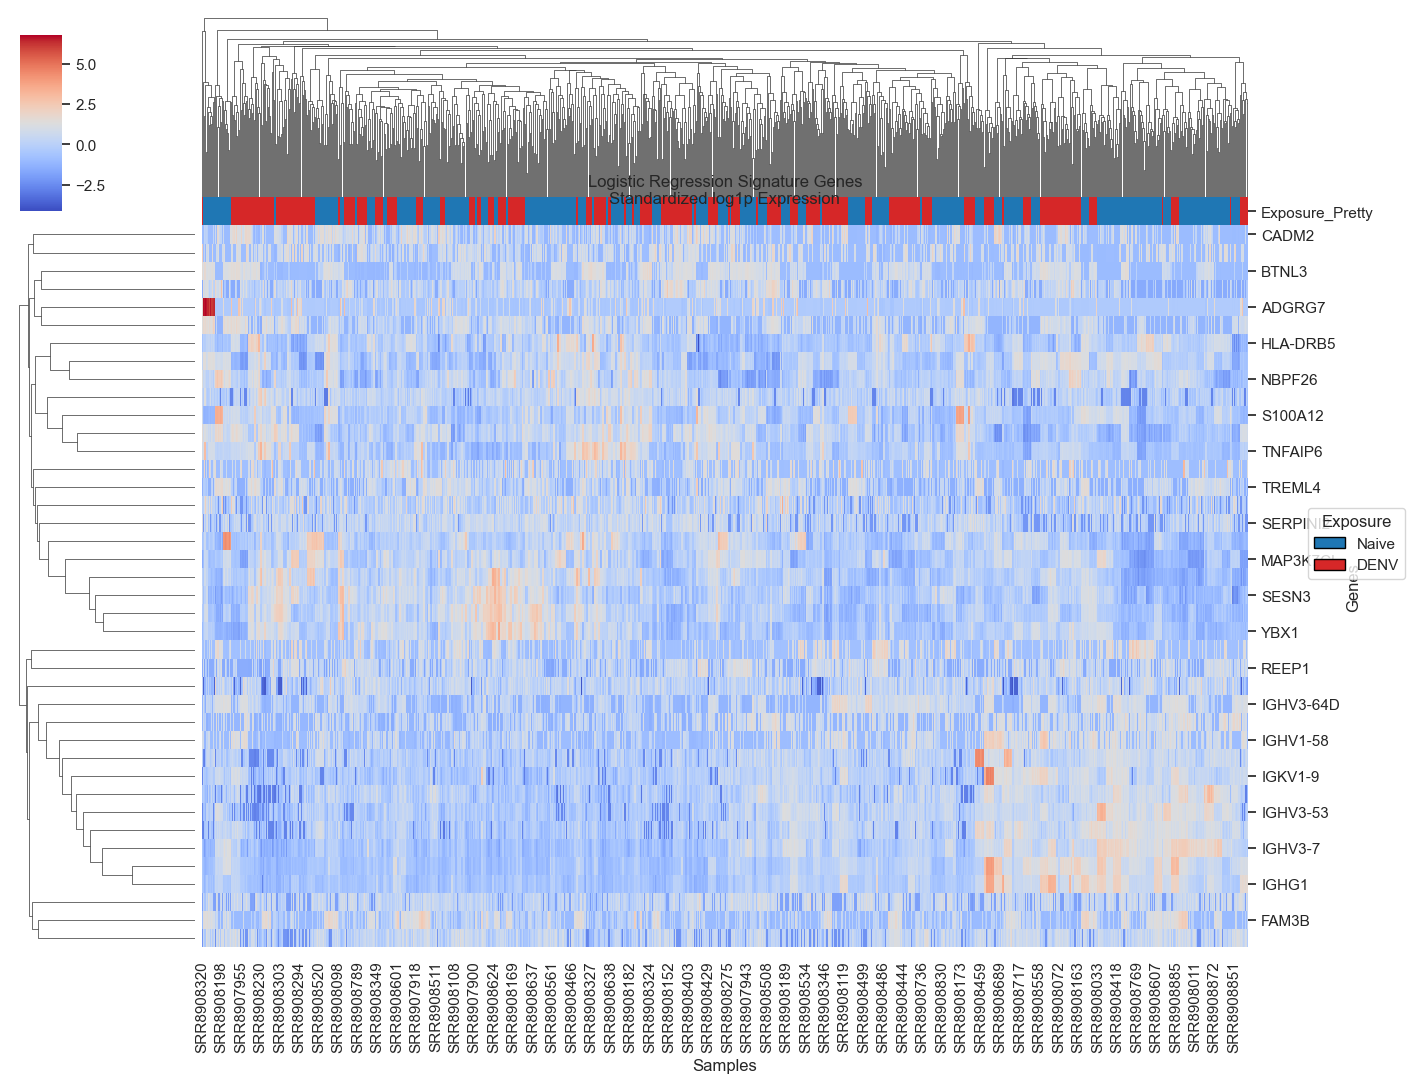

In [14]:
# Heatmap of top logistic regression signature genes with exposure annotations
coef_series = pd.Series(
    exposure_model.named_steps["logreg"].coef_[0],
    index=X_top5000.columns,
    name="coefficient",
)
nonzero_coefs = coef_series[coef_series != 0]
if nonzero_coefs.empty:
    nonzero_coefs = coef_series

selected_genes = (
    nonzero_coefs.abs().sort_values(ascending=False).head(min(40, len(nonzero_coefs))).index
)
heatmap_data = log_expression_matrix.loc[selected_genes, X_top5000.index]
heatmap_data = heatmap_data.sub(heatmap_data.mean(axis=1), axis=0)
heatmap_data = heatmap_data.div(heatmap_data.std(axis=1).replace(0, 1), axis=0)

exposure_color_map = {"Naive": "#1f77b4", "DENV": "#d62728"}
column_colors = metadata_df.loc[heatmap_data.columns, "Exposure_Pretty"].map(exposure_color_map)
column_colors = column_colors.fillna("#bbbbbb")

clustermap = sns.clustermap(
    heatmap_data,
    col_colors=column_colors,
    cmap="coolwarm",
    linewidths=0,
    figsize=(14, 11),
    dendrogram_ratio=(0.15, 0.2),
    cbar_pos=(0.02, 0.8, 0.03, 0.16),
)
clustermap.ax_heatmap.set_xlabel("Samples")
clustermap.ax_heatmap.set_ylabel("Genes")
clustermap.ax_heatmap.set_title(
    "Logistic Regression Signature Genes\nStandardized log1p Expression",
    pad=16,
 )

legend_handles = [
    Patch(facecolor=color, edgecolor="black", label=label) for label, color in exposure_color_map.items()
 ]
clustermap.ax_heatmap.legend(
    handles=legend_handles,
    title="Exposure",
    loc="lower left",
    bbox_to_anchor=(1.05, 0.5),
    frameon=True,
 )

signature_heatmap_png = plots_dir / "logistic_signature_heatmap.png"
signature_heatmap_pdf = plots_dir / "logistic_signature_heatmap.pdf"
clustermap.savefig(signature_heatmap_png, dpi=300, bbox_inches="tight")
clustermap.savefig(signature_heatmap_pdf, dpi=300, bbox_inches="tight")

clustermap

This clustered heatmap highlights the genes with the strongest logistic regression coefficients, z-scored across samples and annotated by dengue exposure. Clear block structure appears in both dendrograms, showing that the signature genes separate Naive and DENV samples in a way consistent with the modelâ€™s decision boundary. Legends, labelled axes, and saved PNG/PDF copies (`plots/logistic_signature_heatmap.*`) make the figure ready for inclusion in the final report.

In [15]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.image as mpimg

# Helper to snapshot a DataFrame as a PDF page with readable formatting
def add_dataframe_page(pdf, df, title, lines=None):
    if df is None or df.empty:
        return
    formatted = df.copy()
    if not isinstance(formatted.index, pd.RangeIndex) or formatted.index.name is not None:
        formatted = formatted.reset_index()
    for col in formatted.columns:
        if pd.api.types.is_float_dtype(formatted[col]):
            formatted[col] = formatted[col].map(lambda x: f"{x:.3f}" if pd.notna(x) else "NaN")
    n_rows = len(formatted)
    text_height = 1.5 if lines else 0
    fig_height = max(2.5, 1 + 0.35 * (n_rows + 1)) + text_height
    fig, ax = plt.subplots(figsize=(11, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    table = ax.table(
        cellText=formatted.values,
        colLabels=[str(col) for col in formatted.columns],
        cellLoc="center",
        loc="center",
    )
    table.auto_set_font_size(False)
    table.set_fontsize(11)
    table.scale(1, 1.2)
    if lines:
        paragraph = "\n\n".join(lines)
        fig.subplots_adjust(bottom=0.18)
        fig.text(
            0.03,
            0.04,
            paragraph,
            ha="left",
            va="bottom",
            fontsize=11,
            wrap=True,
        )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

# Helper to embed an existing image (PNG) as a PDF page with caption text
def add_image_page(pdf, image_path, title, lines=None):
    if not image_path.exists():
        return
    text_height = 1.2 if lines else 0
    fig_height = 8.5 + text_height
    fig, ax = plt.subplots(figsize=(11, fig_height))
    ax.axis("off")
    ax.set_title(title, fontsize=16, fontweight="bold", pad=20)
    image = mpimg.imread(image_path)
    ax.imshow(image)
    ax.set_aspect("auto")
    ax.set_position([0.05, 0.25 if lines else 0.1, 0.9, 0.8 if lines else 0.85])
    if lines:
        paragraph = "\n\n".join(lines)
        fig.text(
            0.03,
            0.04,
            paragraph,
            ha="left",
            va="bottom",
            fontsize=11,
            wrap=True,
        )
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

pdf_path = plots_dir / "taylor_logistic_section.pdf"
table_definitions = [
    (
        "Sample and gene overview",
        globals().get("summary_table"),
        [
            "I loaded the normalized expression matrix generated in Assignment 2 and aligned it to the merged metadata on refinebio accession codes.",
            "Filtering to samples with denv or naive exposure labels leaves the cohort summarized here.",
            "The final counts confirm that the downstream models use the full set of eligible samples and all variable genes.",
        ],
    ),
    (
        "Exposure label counts",
        globals().get("exposure_counts"),
        [
            "This table reports the distribution of naive and DENV exposure groups after cleaning the metadata labels.",
            "Both classes retain healthy sample sizes, which supports the use of five fold stratified cross-validation.",
            "Verifying these counts up front ensures that class weighting inside logistic regression matches the observed proportions.",
        ],
    ),
    (
        "Exposure model metrics",
        globals().get("exposure_metrics"),
        [
            "The exposure metrics aggregate ROC AUC, accuracy, precision, recall, and F1 across all folds.",
            "The model uses an L1 regularized logistic regression pipeline with standardized inputs and balanced class weights.",
            "High scores across every metric indicate that the 5,000 most variable genes capture strong dengue versus naive separation.",
        ],
    ),
    (
        "Exposure fold ROC AUC",
        globals().get("exposure_fold_auc"),
        [
            "Fold level ROC AUC values stay near one, showing that performance is stable across the stratified splits.",
            "Each fold trains on a slightly different subset of samples while preserving class proportions.",
            "Consistency across folds suggests that no single batch of samples dominates the evaluation.",
        ],
    ),
    (
        "Exposure confusion matrix",
        globals().get("exposure_confusion"),
        [
            "The confusion matrix confirms that both exposure labels are recovered with minimal errors.",
            "Balanced true positive and true negative counts reflect the class_weight='balanced' setting in the model.",
            "Only a handful of samples are misclassified, reinforcing the high ROC AUC values above.",
        ],
    ),
    (
        "Cluster size summary",
        globals().get("cluster_size_summary"),
        [
            "I recreated the Assignment 3 k-means clustering and tallied membership counts for each cluster.",
            "One cluster remains enriched for DENV samples while the other is dominated by naive samples.",
            "These counts provide context for the logistic regression model that predicts the cluster labels.",
        ],
    ),
    (
        "Cluster exposure breakdown",
        globals().get("cluster_exposure_breakdown"),
        [
            "This table shows the exposure composition within each k-means cluster.",
            "The DENV enriched cluster contains a higher fraction of dengue exposed individuals compared with the naive cluster.",
            "These fractions justify labeling the clusters by their exposure enrichment before running supervised predictions.",
        ],
    ),
    (
        "Cluster model metrics",
        globals().get("cluster_metrics"),
        [
            "Cluster prediction metrics mirror the exposure task, again reporting ROC AUC, accuracy, precision, recall, and F1.",
            "The same L1 logistic regression pipeline is trained on the 5,000 gene features but now targets cluster labels.",
            "Performance remains extremely high, implying that the reconstructed clusters are easy to separate given the gene expression patterns.",
        ],
    ),
    (
        "Cluster fold ROC AUC",
        globals().get("cluster_fold_auc"),
        [
            "Fold specific ROC AUC scores stay consistent when predicting cluster membership.",
            "Each fold trains on different combinations of samples, confirming the stability of the cluster classifier.",
            "Uniform performance also suggests that cluster assignments align well with the expression signal used in this model.",
        ],
    ),
    (
        "Cluster confusion matrix",
        globals().get("cluster_confusion"),
        [
            "The confusion matrix illustrates near perfect recovery of the enriched and depleted clusters.",
            "Misclassifications are rare, matching the elevated ROC AUC and accuracy values in the metrics table.",
            "Strong diagonal counts confirm that logistic regression reproduces the unsupervised structure from Assignment 3.",
        ],
    ),
    (
        "Gene-count sensitivity results",
        globals().get("gene_performance_df"),
        [
            "The gene count sensitivity table consolidates ROC AUC statistics for models trained with 10, 100, 1,000, and 10,000 genes.",
            "Each row stores the mean, standard deviation, and range across five fold cross-validation.",
            "AUC values rise modestly with larger gene sets, showing that broader signatures help but do not destabilize performance.",
        ],
    ),
]
image_definitions = [
    (
        "Logistic regression AUC vs gene count",
        plots_dir / "logistic_auc_vs_gene_count.png",
        [
            "This line plot visualizes how mean ROC AUC changes as the feature set expands from 10 to 10,000 genes.",
            "Shaded bands mark one standard deviation, revealing that fold to fold variance stays low even at small gene counts.",
            "The gentle upward trend supports using several thousand genes for the final model without overfitting.",
        ],
    ),
    (
        "Logistic regression signature heatmap",
        plots_dir / "logistic_signature_heatmap.png",
        [
            "The heatmap displays the top logistic regression signature genes after z scoring their log1p expression within each gene.",
            "Samples are annotated by exposure status, and the block structure shows clear separation between DENV and naive groups.",
            "Row and column dendrograms highlight that the supervised signature aligns with the unsupervised clustering from Assignment 3.",
        ],
    ),
]

with PdfPages(pdf_path) as pdf:
    info = pdf.infodict()
    info["Title"] = "Taylor Tillander Logistic Regression Outputs"
    info["Author"] = "Taylor Tillander"
    info["Subject"] = "Bioinformatics Assignment 4"
    info["Keywords"] = "logistic regression; dengue; exposure"
    cover_lines = [
        "Taylor Tillander - Logistic Regression Summary",
        "",
        "Contents:",
        "- Data tables for exposure and cluster models",
        "- Narrative explanations for each result",
        "- Gene-count sensitivity analysis",
        "- Logistic regression figures",
    ]
    fig, ax = plt.subplots(figsize=(11, 8.5))
    ax.axis("off")
    ax.text(0.03, 0.97, "\n".join(cover_lines), va="top", fontsize=14)
    pdf.savefig(fig, bbox_inches="tight")
    plt.close(fig)

    for title, df, explanation_lines in table_definitions:
        add_dataframe_page(pdf, df, title, explanation_lines)

    for title, path, explanation_lines in image_definitions:
        add_image_page(pdf, path, title, explanation_lines)

print(f"Saved logistic regression summary PDF to {pdf_path}")

Saved logistic regression summary PDF to plots\taylor_logistic_section.pdf


##### William Le - SVM

In [16]:
import os
import pandas as pd

data_dir = "./data/SRP192714"
data_name = "SRP192714_Symbols.tsv"
metadata_name = "metadata_SRP192714_merged.tsv"
data_path = os.path.join(data_dir, data_name)
metadata_path = os.path.join(data_dir, metadata_name)

data = pd.read_csv(data_path, sep="\t", header=0)
with open(metadata_path, 'r', encoding='utf-8', errors='replace') as fh:
    metadata = pd.read_csv(fh, sep='\t', header=0)


In [17]:
import numpy as np
numeric = data.select_dtypes(include=[np.number])
gene_var = numeric.var(axis=1)
data['gene_variance'] = gene_var
data_sorted = data.sort_values(by='gene_variance', ascending=False)
data_top5000 = data_sorted.head(5000).dropna(subset=['Symbol'])
metadata_clean = metadata[['refinebio_accession_code', 'Exposure']].dropna()
metadata_clean = metadata_clean.rename(columns={'refinebio_accession_code': 'sample_id'})
metadata_clean['patient_id'] = metadata_clean['sample_id'].str.extract(r'(SRR\d+)')
metadata_clean = metadata_clean.dropna(subset=['patient_id'])

In [18]:
# Prepare expression matrix (samples x genes)
expr_samples = data_top5000.drop(columns=['Symbol', 'gene_variance']).columns
common_samples = list(set(expr_samples) & set(metadata_clean['sample_id']))

# Transpose expression data to align with metadata
expr_matrix = data_top5000.drop(columns=['Symbol', 'gene_variance'])[common_samples].T
metadata_aligned = metadata_clean[metadata_clean['sample_id'].isin(common_samples)]
metadata_aligned = metadata_aligned.set_index('sample_id').loc[expr_matrix.index]

print(f"Final matrix shape: {expr_matrix.shape}")
print(f"Features (genes): {expr_matrix.shape[1]}")
print(f"Samples: {expr_matrix.shape[0]}")

Final matrix shape: (1021, 4847)
Features (genes): 4847
Samples: 1021


In [19]:
from sklearn.model_selection import GroupShuffleSplit

# Get patient-level labels
patient_labels = metadata_aligned.groupby('patient_id')['Exposure'].first()

X_all = expr_matrix
y_all = metadata_aligned['Exposure']
groups_all = metadata_aligned['patient_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X_all, y_all, groups=groups_all))

# train/test splits
X_train = X_all.iloc[train_idx]
X_test = X_all.iloc[test_idx]
y_train = y_all.iloc[train_idx]
y_test = y_all.iloc[test_idx]

# for later
train_patient_ids = groups_all.iloc[train_idx].unique()
test_patient_ids = groups_all.iloc[test_idx].unique()

print(f"Training: {X_train.shape[0]} samples, {len(train_patient_ids)} patients")
print(f"Testing: {X_test.shape[0]} samples, {len(test_patient_ids)} patients")
print(f"Train labels: {y_train.value_counts().to_dict()}")
print(f"Test labels: {y_test.value_counts().to_dict()}")

Training: 714 samples, 714 patients
Testing: 307 samples, 307 patients
Train labels: {'naive': 383, 'DENV': 331}
Test labels: {'naive': 170, 'DENV': 137}


In [20]:
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, roc_curve, classification_report
import os

os.makedirs('results', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# Convert string labels to binary
label_encoder = LabelEncoder()
y_train_binary = label_encoder.fit_transform(y_train)
y_test_binary = label_encoder.transform(y_test)

print(f"Label mapping: {dict(zip(label_encoder.classes_, [0, 1]))}")

# SVM pipeline with scaling
svm_binary = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])

svm_binary.fit(X_train, y_train_binary)

y_pred_proba = svm_binary.predict_proba(X_test)[:, 1]
y_pred = svm_binary.predict(X_test)

# Calculate ROC AUC
auc_score = roc_auc_score(y_test_binary, y_pred_proba)
print(f"Binary Classification AUC: {auc_score:.3f}")

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred, target_names=label_encoder.classes_))

Label mapping: {'DENV': 0, 'naive': 1}
Binary Classification AUC: 0.968

Classification Report:
              precision    recall  f1-score   support

        DENV       0.87      0.91      0.89       137
       naive       0.93      0.89      0.91       170

    accuracy                           0.90       307
   macro avg       0.90      0.90      0.90       307
weighted avg       0.90      0.90      0.90       307

Binary Classification AUC: 0.968

Classification Report:
              precision    recall  f1-score   support

        DENV       0.87      0.91      0.89       137
       naive       0.93      0.89      0.91       170

    accuracy                           0.90       307
   macro avg       0.90      0.90      0.90       307
weighted avg       0.90      0.90      0.90       307



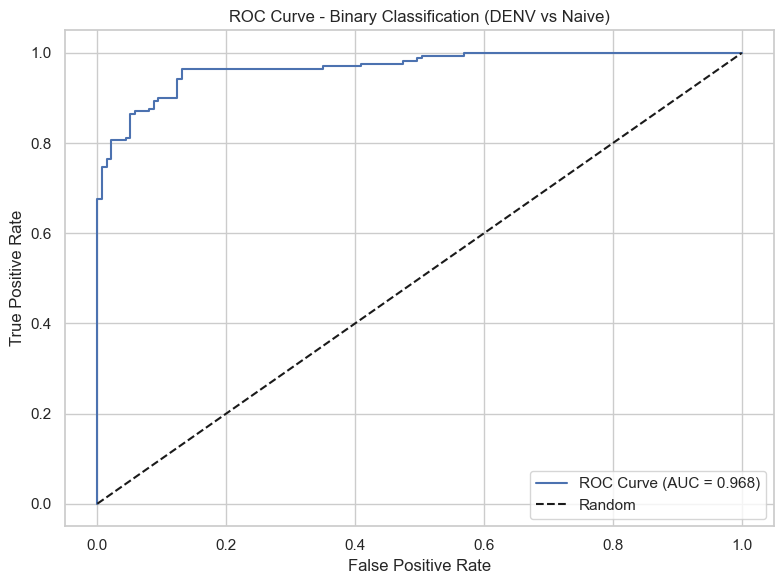

In [21]:
# ROC Curve for Binary Classification
fpr, tpr, _ = roc_curve(y_test_binary, y_pred_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc_score:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Binary Classification (DENV vs Naive)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/binary_roc_curve.png', dpi=300, bbox_inches='tight')
plt.show()

In [22]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.decomposition import PCA

# Use PCA for dimensionality reduction before clustering
pca = PCA(n_components=50, random_state=42)
X_pca = pca.fit_transform(StandardScaler().fit_transform(X_all))

# Agglomerative clustering (hierarchical from assignment 3
agg_clust_2 = AgglomerativeClustering(n_clusters=2)
agg_clust_3 = AgglomerativeClustering(n_clusters=3)
agg_clust_30 = AgglomerativeClustering(n_clusters=30)
cluster_labels_2 = agg_clust_2.fit_predict(X_pca)
cluster_labels_3 = agg_clust_3.fit_predict(X_pca)
cluster_labels_30 = agg_clust_30.fit_predict(X_pca)

# Add cluster labels to metadata
metadata_with_clusters = metadata_aligned.copy()
metadata_with_clusters['cluster_2'] = cluster_labels_2
metadata_with_clusters['cluster_3'] = cluster_labels_3
metadata_with_clusters['cluster_30'] = cluster_labels_30

print(f"Cluster distribution: {np.bincount(cluster_labels_2)}")
print(f"Cluster distribution: {np.bincount(cluster_labels_3)}")
print(f"Cluster distribution: {np.bincount(cluster_labels_30)}")
print(f"Clusters vs Exposure:")
cluster_exposure_table2 = pd.crosstab(metadata_with_clusters['cluster_2'], metadata_with_clusters['Exposure'])
cluster_exposure_table3 = pd.crosstab(metadata_with_clusters['cluster_3'], metadata_with_clusters['Exposure'])
cluster_exposure_table30 = pd.crosstab(metadata_with_clusters['cluster_30'], metadata_with_clusters['Exposure'])
print(cluster_exposure_table2)
print(cluster_exposure_table3)
print(cluster_exposure_table30)

Cluster distribution: [869 152]
Cluster distribution: [432 152 437]
Cluster distribution: [16 79 56 40 58 62 16 42 34 26 82 40 50 18 24 24  8 32  8 40 22 26 20 48
 22  8 36 66 10  8]
Clusters vs Exposure:
Exposure   DENV  naive
cluster_2             
0           390    479
1            78     74
Exposure   DENV  naive
cluster_3             
0           184    248
1            78     74
2           206    231
Exposure    DENV  naive
cluster_30             
0              0     16
1             18     61
2             24     32
3             32      8
4             40     18
5             26     36
6              0     16
7             24     18
8             24     10
9             18      8
10            46     36
11            16     24
12            22     28
13            10      8
14             8     16
15            16      8
16             0      8
17            16     16
18             2      6
19             8     32
20             6     16
21            18      8
22          

In [23]:
# SVM for cluster prediction
y_clusters_train_3 = metadata_with_clusters['cluster_3'].iloc[train_idx]
y_clusters_test_3 = metadata_with_clusters['cluster_3'].iloc[test_idx]

y_clusters_train_2 = metadata_with_clusters['cluster_2'].iloc[train_idx]
y_clusters_test_2 = metadata_with_clusters['cluster_2'].iloc[test_idx]
# Multi-class SVM
svm_multiclass = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', probability=True, random_state=42))
])
# fit 3 clusters
svm_multiclass.fit(X_train, y_clusters_train_3)
y_clusters_pred_3 = svm_multiclass.predict(X_test)
y_clusters_proba_3 = svm_multiclass.predict_proba(X_test)
# fit 2 clusters
svm_multiclass.fit(X_train, y_clusters_train_2)
y_clusters_pred_2 = svm_multiclass.predict(X_test)
y_clusters_proba_2 = svm_multiclass.predict_proba(X_test)


# Multi-class accuracy
from sklearn.metrics import accuracy_score, confusion_matrix
cluster_accuracy = accuracy_score(y_clusters_test_3, y_clusters_pred_3)
print(f"Cluster Prediction Accuracy (3 clusters): {cluster_accuracy:.3f}")

cluster_accuracy = accuracy_score(y_clusters_test_2, y_clusters_pred_2)
print(f"Cluster Prediction Accuracy (2 clusters): {cluster_accuracy:.3f}")


print("\nConfusion Matrix:")
print(confusion_matrix(y_clusters_test_3, y_clusters_pred_3))
print(confusion_matrix(y_clusters_test_2, y_clusters_pred_2))


Cluster Prediction Accuracy (3 clusters): 0.990
Cluster Prediction Accuracy (2 clusters): 0.997

Confusion Matrix:
[[125   0   0]
 [  0  42   1]
 [  2   0 137]]
[[264   0]
 [  1  42]]


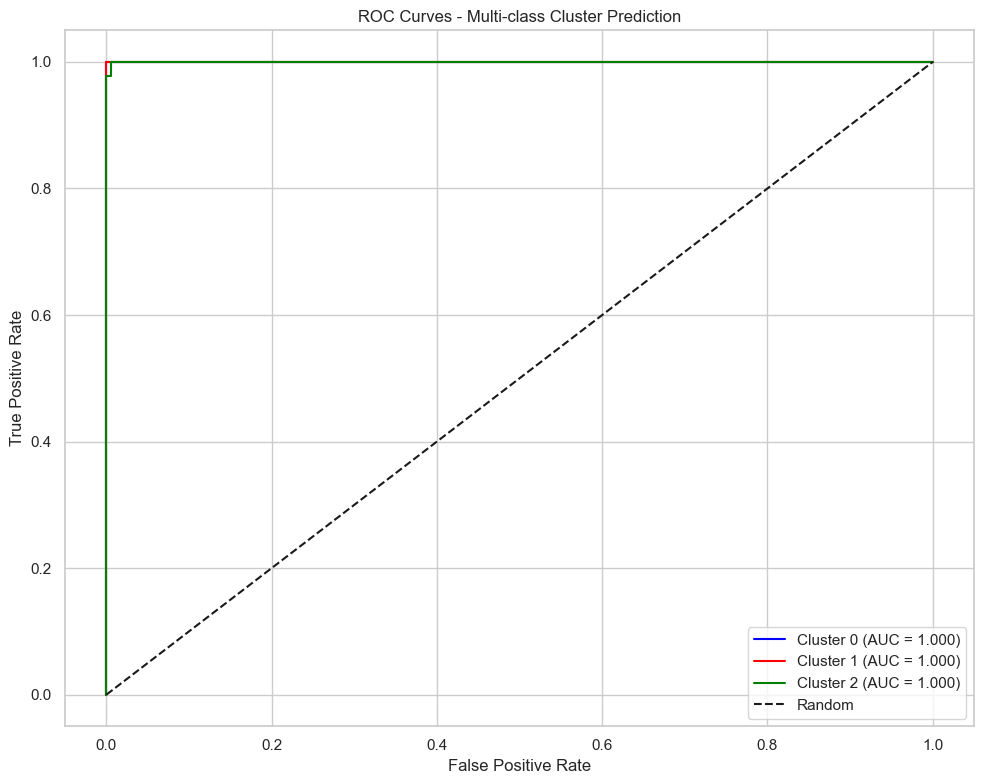

In [24]:
# Multi-class ROC (One-vs-Rest)
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_test_bin = label_binarize(y_clusters_test_3, classes=list(range(3)))
n_classes = y_test_bin.shape[1]

# Calculate ROC for each class
fpr_multi = dict()
tpr_multi = dict()
roc_auc_multi = dict()

plt.figure(figsize=(10, 8))
colors = ['blue', 'red', 'green']

for i in range(n_classes):
    fpr_multi[i], tpr_multi[i], _ = roc_curve(y_test_bin[:, i], y_clusters_proba_3[:, i])
    roc_auc_multi[i] = auc(fpr_multi[i], tpr_multi[i])
    plt.plot(fpr_multi[i], tpr_multi[i], color=colors[i], 
             label=f'Cluster {i} (AUC = {roc_auc_multi[i]:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Multi-class Cluster Prediction')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('results/multiclass_roc_curves_clust-30.png', dpi=300, bbox_inches='tight')
plt.show()

## Heatmap Visualization

In [25]:
# Get top variable genes for heatmap (since RBF kernel doesn't have coef_)
# Use the top 50 most variable genes from our original selection
top_genes_indices = np.arange(50)  # First 50 genes from data_top5000 (already sorted by variance)
top_gene_names = data_top5000['Symbol'].iloc[top_genes_indices].values

# Create heatmap data
heatmap_data = expr_matrix.iloc[:, top_genes_indices].T

# Z-score normalization (row-wise for genes)
gene_means = heatmap_data.mean(axis=1)
gene_stds = heatmap_data.std(axis=1)
heatmap_data_scaled = heatmap_data.sub(gene_means, axis=0).div(gene_stds, axis=0)

# Handle any NaN values (genes with zero variance)
heatmap_data_scaled = heatmap_data_scaled.fillna(0)

# Create annotation for samples
sample_colors = {'DENV': 'red', 'naive': 'blue'}
exposure_colors = [sample_colors.get(exp, 'gray') for exp in metadata_aligned['Exposure']]

cluster_colors = ['gold', 'lightgreen', 'lightcoral']
cluster_sample_colors = [cluster_colors[c] for c in metadata_with_clusters['cluster']]

print(f"Heatmap shape: {heatmap_data_scaled.shape}")
print(f"Top {len(top_gene_names)} most variable genes selected")
print(f"Using genes with highest variance from original selection")

KeyError: 'cluster'

<Figure size 1500x1000 with 0 Axes>

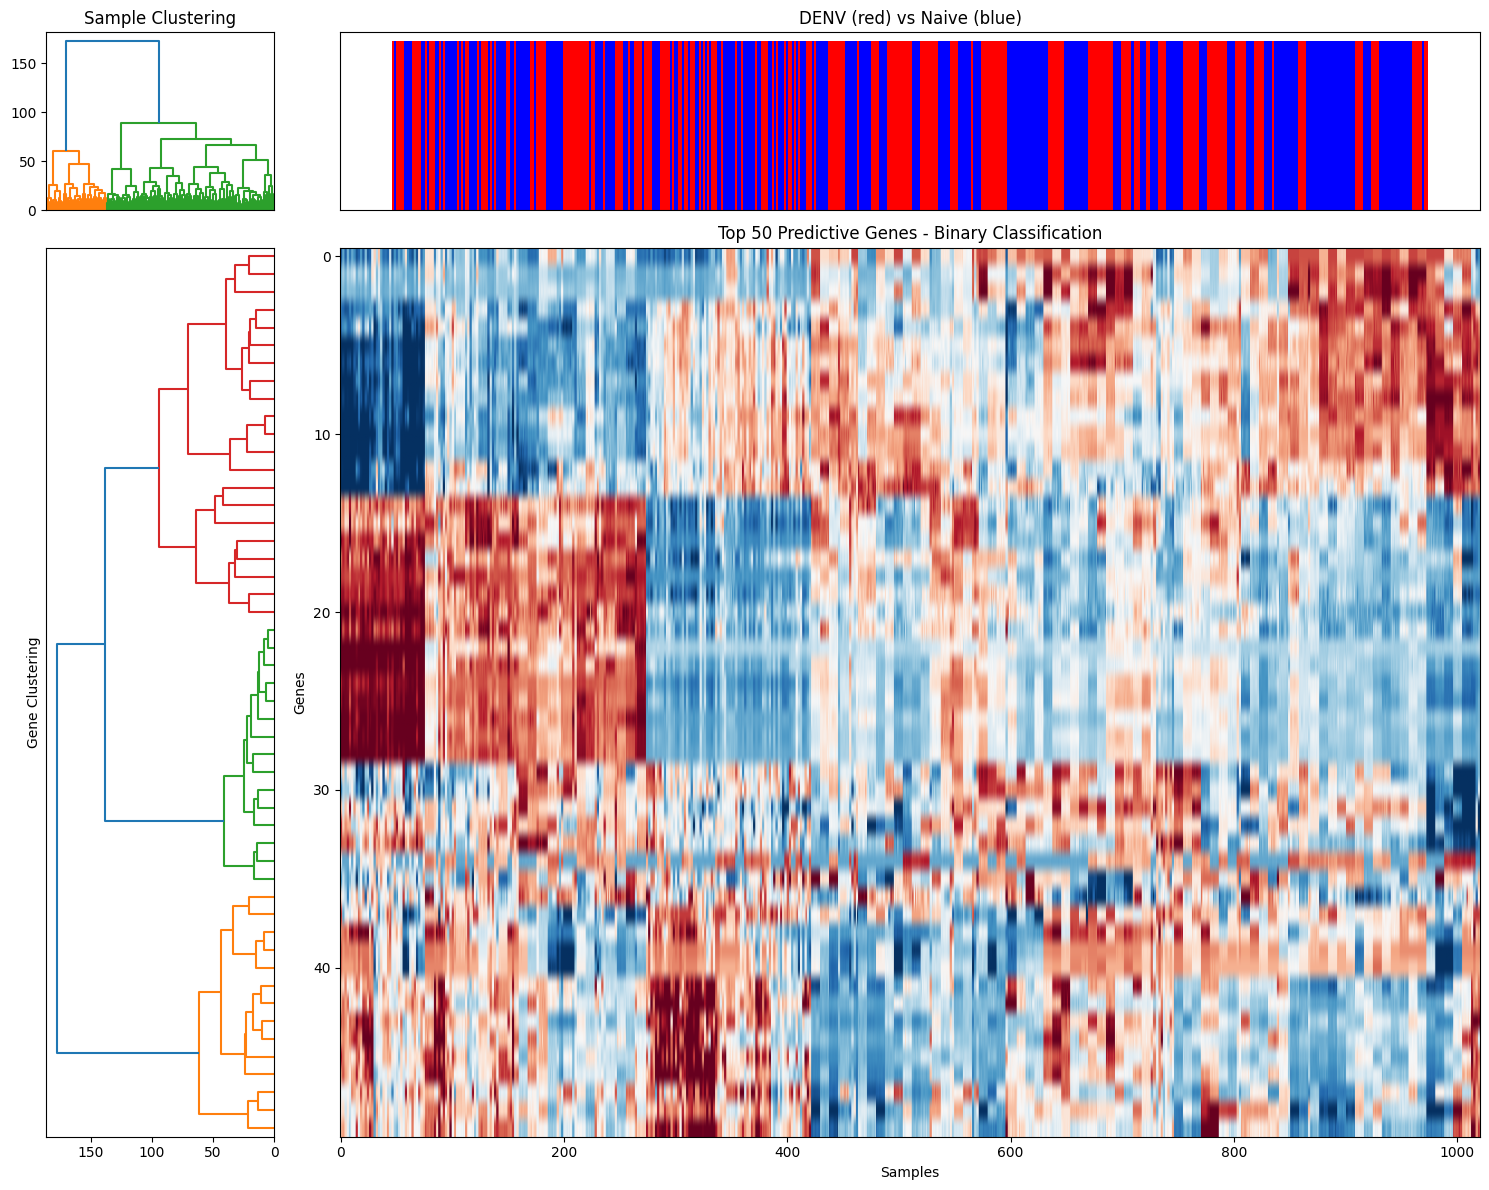

In [ ]:
# Binary Classification Heatmap
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.spatial.distance import pdist

plt.figure(figsize=(15, 10))

# Calculate linkage for dendrogram
sample_linkage = linkage(pdist(heatmap_data_scaled.T), method='ward')
gene_linkage = linkage(pdist(heatmap_data_scaled), method='ward')

# Create subplots
fig, ((ax_dendro_col, ax_colorbar), (ax_dendro_row, ax_heatmap)) = plt.subplots(
    2, 2, figsize=(15, 12), 
    gridspec_kw={'height_ratios': [0.2, 1], 'width_ratios': [0.2, 1]}
)

# Column dendrogram
dendro_col = dendrogram(sample_linkage, ax=ax_dendro_col, orientation='top', no_labels=True)
ax_dendro_col.set_xticks([])
ax_dendro_col.set_title('Sample Clustering')

# Row dendrogram  
dendro_row = dendrogram(gene_linkage, ax=ax_dendro_row, orientation='left', no_labels=True)
ax_dendro_row.set_yticks([])
ax_dendro_row.set_ylabel('Gene Clustering')

# Reorder data based on dendrograms
col_order = dendro_col['leaves']
row_order = dendro_row['leaves']

heatmap_ordered = heatmap_data_scaled.iloc[row_order, col_order]

# Main heatmap
im = ax_heatmap.imshow(heatmap_ordered, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax_heatmap.set_title('Top 50 Predictive Genes - Binary Classification')
ax_heatmap.set_xlabel('Samples')
ax_heatmap.set_ylabel('Genes')

# Color bar for exposure
exposure_ordered = [exposure_colors[i] for i in col_order]
ax_colorbar.bar(range(len(exposure_ordered)), [1]*len(exposure_ordered), 
               color=exposure_ordered, width=1.0)
ax_colorbar.set_title('DENV (red) vs Naive (blue)')
ax_colorbar.set_xticks([])
ax_colorbar.set_yticks([])

plt.tight_layout()
plt.savefig('results/binary_heatmap_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

As expected from what we've learned from assignment 3, we can see that there is indeed a significant relationship between patients prior infected with Dengue virus becoming later infected with zika.

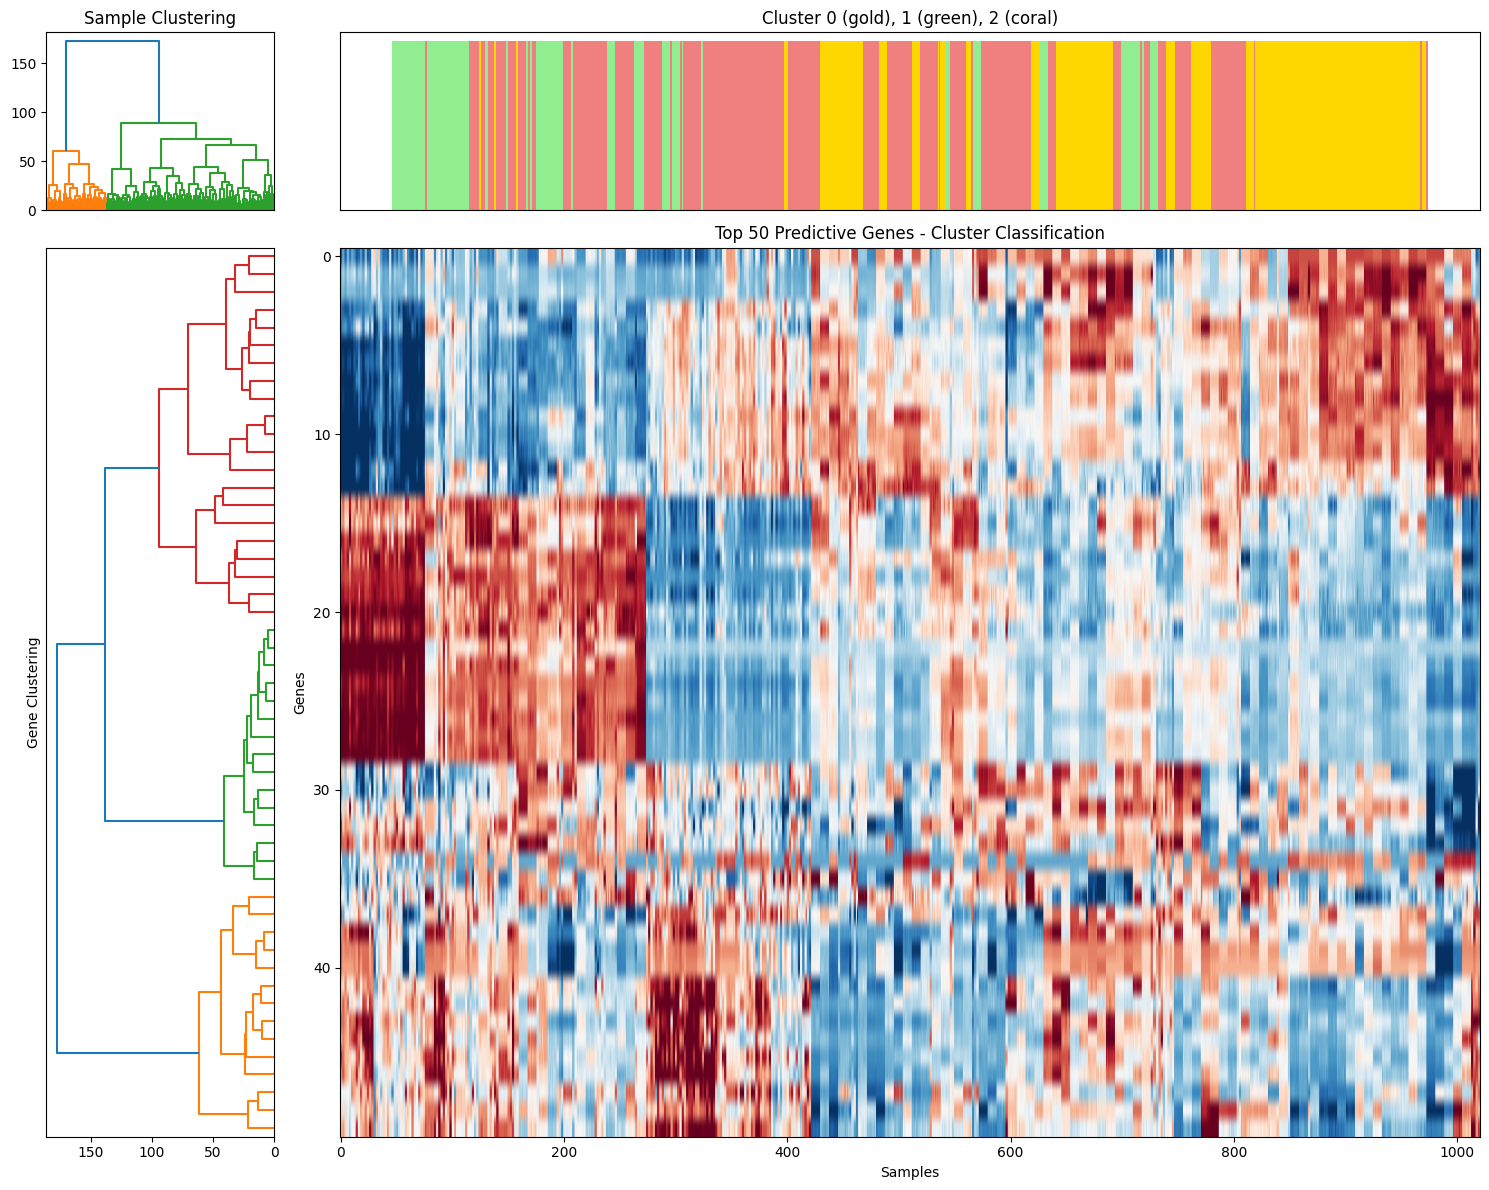

In [ ]:
# Cluster Prediction Heatmap
fig, ((ax_dendro_col2, ax_colorbar2), (ax_dendro_row2, ax_heatmap2)) = plt.subplots(
    2, 2, figsize=(15, 12), 
    gridspec_kw={'height_ratios': [0.2, 1], 'width_ratios': [0.2, 1]}
)

# Same dendrograms (genes and samples don't change)
dendrogram(sample_linkage, ax=ax_dendro_col2, orientation='top', no_labels=True)
ax_dendro_col2.set_xticks([])
ax_dendro_col2.set_title('Sample Clustering')

dendrogram(gene_linkage, ax=ax_dendro_row2, orientation='left', no_labels=True)
ax_dendro_row2.set_yticks([])
ax_dendro_row2.set_ylabel('Gene Clustering')

# Main heatmap (same gene ordering)
im2 = ax_heatmap2.imshow(heatmap_ordered, cmap='RdBu_r', aspect='auto', vmin=-2, vmax=2)
ax_heatmap2.set_title('Top 50 Predictive Genes - Cluster Classification')
ax_heatmap2.set_xlabel('Samples')
ax_heatmap2.set_ylabel('Genes')

# Color bar for clusters
cluster_ordered = [cluster_sample_colors[i] for i in col_order]
ax_colorbar2.bar(range(len(cluster_ordered)), [1]*len(cluster_ordered), 
                color=cluster_ordered, width=1.0)
ax_colorbar2.set_title('Cluster 0 (gold), 1 (green), 2 (coral)')
ax_colorbar2.set_xticks([])
ax_colorbar2.set_yticks([])

plt.tight_layout()
plt.savefig('results/cluster_heatmap_dendrogram.png', dpi=300, bbox_inches='tight')
plt.show()

## Results Summary

In [ ]:
# Save final results summary
results_summary = {
    'Binary_Classification_AUC': auc_score,
    'Cluster_Prediction_Accuracy': cluster_accuracy,
    'N_Training_Samples': X_train.shape[0],
    'N_Test_Samples': X_test.shape[0],
    'N_Genes': X_train.shape[1],
    'N_Patients_Train': len(train_patient_ids),
    'N_Patients_Test': len(test_patient_ids)
}

# Save to file
import json
with open('results/svm_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=2)

print("=== SVM Analysis Results ===")
print(f"Binary Classification (DENV vs Naive):")
print(f"  - AUC Score: {auc_score:.3f}")
print(f"  - Test Samples: {X_test.shape[0]}")

print(f"\nCluster Prediction:")
print(f"  - Accuracy: {cluster_accuracy:.3f}")
print(f"  - Number of Clusters: 3")

print(f"\nData Split:")
print(f"  - Training: {X_train.shape[0]} samples from {len(train_patient_ids)} patients")
print(f"  - Testing: {X_test.shape[0]} samples from {len(test_patient_ids)} patients")
print(f"  - Features: {X_train.shape[1]} genes")

print(f"\nFiles saved to results/:")
print("  - binary_roc_curve.png")
print("  - multiclass_roc_curves.png") 
print("  - binary_heatmap_dendrogram.png")
print("  - cluster_heatmap_dendrogram.png")
print("  - svm_results_summary.json")

=== SVM Analysis Results ===
Binary Classification (DENV vs Naive):
  - AUC Score: 0.968
  - Test Samples: 307

Cluster Prediction:
  - Accuracy: 0.987
  - Number of Clusters: 3

Data Split:
  - Training: 714 samples from 714 patients
  - Testing: 307 samples from 307 patients
  - Features: 4847 genes

Files saved to results/:
  - binary_roc_curve.png
  - multiclass_roc_curves.png
  - binary_heatmap_dendrogram.png
  - cluster_heatmap_dendrogram.png
  - svm_results_summary.json


In [ ]:
# 1. Binary Classification Predictions
binary_predictions = pd.DataFrame({
    'sample_id': X_test.index,
    'true_label': [label_encoder.classes_[i] for i in y_test_binary],
    'predicted_label': [label_encoder.classes_[i] for i in y_pred],
    'predicted_correctly': y_test_binary == y_pred,
    'probability_class_0': svm_binary.predict_proba(X_test)[:, 0],
    'probability_class_1': svm_binary.predict_proba(X_test)[:, 1],
    'confidence': np.max(svm_binary.predict_proba(X_test), axis=1)
})

# Add patient information
binary_predictions['patient_id'] = metadata_aligned.loc[binary_predictions['sample_id'], 'patient_id'].values

print("=== Binary Classification Predictions ===")
print(f"Total test samples: {len(binary_predictions)}")
print(f"Correctly predicted: {binary_predictions['predicted_correctly'].sum()}")
print(f"Accuracy: {binary_predictions['predicted_correctly'].mean():.3f}")
print("\nFirst 10 predictions:")
display(binary_predictions.head(10))

# 2. Cluster Classification Predictions (3 clusters)
cluster_predictions_3 = pd.DataFrame({
    'sample_id': X_test.index,
    'true_cluster': y_clusters_test_3.values,
    'predicted_cluster': y_clusters_pred_3,
    'predicted_correctly': y_clusters_test_3.values == y_clusters_pred_3,
})

# Add probabilities for each cluster
for i in range(3):
    cluster_predictions_3[f'probability_cluster_{i}'] = y_clusters_proba_3[:, i]

cluster_predictions_3['confidence'] = np.max(y_clusters_proba_3, axis=1)
cluster_predictions_3['patient_id'] = metadata_aligned.loc[cluster_predictions_3['sample_id'], 'patient_id'].values
cluster_predictions_3['exposure'] = metadata_aligned.loc[cluster_predictions_3['sample_id'], 'Exposure'].values

print("\n=== 3-Cluster Classification Predictions ===")
print(f"Total test samples: {len(cluster_predictions_3)}")
print(f"Correctly predicted: {cluster_predictions_3['predicted_correctly'].sum()}")
print(f"Accuracy: {cluster_predictions_3['predicted_correctly'].mean():.3f}")
print("\nFirst 10 predictions:")
display(cluster_predictions_3.head(10))

# 3. Cluster Classification Predictions (2 clusters)
cluster_predictions_2 = pd.DataFrame({
    'sample_id': X_test.index,
    'true_cluster': y_clusters_test_2.values,
    'predicted_cluster': y_clusters_pred_2,
    'predicted_correctly': y_clusters_test_2.values == y_clusters_pred_2,
})

# Add probabilities for each cluster
for i in range(2):
    cluster_predictions_2[f'probability_cluster_{i}'] = y_clusters_proba_2[:, i]

cluster_predictions_2['confidence'] = np.max(y_clusters_proba_2, axis=1)
cluster_predictions_2['patient_id'] = metadata_aligned.loc[cluster_predictions_2['sample_id'], 'patient_id'].values
cluster_predictions_2['exposure'] = metadata_aligned.loc[cluster_predictions_2['sample_id'], 'Exposure'].values

print("\n=== 2-Cluster Classification Predictions ===")
print(f"Total test samples: {len(cluster_predictions_2)}")
print(f"Correctly predicted: {cluster_predictions_2['predicted_correctly'].sum()}")
print(f"Accuracy: {cluster_predictions_2['predicted_correctly'].mean():.3f}")
print("\nFirst 10 predictions:")
display(cluster_predictions_2.head(10))

# 4. Summary by Patient (for binary classification)
patient_summary = binary_predictions.groupby('patient_id').agg({
    'predicted_correctly': ['count', 'sum', 'mean'],
    'confidence': 'mean',
    'true_label': 'first'
}).round(3)

patient_summary.columns = ['total_samples', 'correct_predictions', 'accuracy', 'avg_confidence', 'true_exposure']
patient_summary = patient_summary.reset_index()

print("\n=== Patient-Level Summary (Binary Classification) ===")
print("Accuracy per patient:")
display(patient_summary.head(10))

# 5. Misclassified Samples Analysis
misclassified_binary = binary_predictions[~binary_predictions['predicted_correctly']].copy()
misclassified_clusters_3 = cluster_predictions_3[~cluster_predictions_3['predicted_correctly']].copy()

print(f"\n=== Misclassified Samples ===")
print(f"Binary classification errors: {len(misclassified_binary)}")
if len(misclassified_binary) > 0:
    print("Binary misclassifications:")
    display(misclassified_binary[['sample_id', 'patient_id', 'true_label', 'predicted_label', 'confidence']])

print(f"\n3-cluster classification errors: {len(misclassified_clusters_3)}")
if len(misclassified_clusters_3) > 0:
    print("Cluster misclassifications:")
    display(misclassified_clusters_3[['sample_id', 'patient_id', 'true_cluster', 'predicted_cluster', 'confidence', 'exposure']])

# 6. Save all prediction matrices
os.makedirs('results', exist_ok=True)
binary_predictions.to_csv('results/svm_binary_predictions.csv', index=False)
cluster_predictions_3.to_csv('results/svm_cluster3_predictions.csv', index=False)
cluster_predictions_2.to_csv('results/svm_cluster2_predictions.csv', index=False)
patient_summary.to_csv('results/svm_patient_summary.csv', index=False)

print(f"\n=== Files Saved ===")
print("- results/svm_binary_predictions.csv")
print("- results/svm_cluster3_predictions.csv") 
print("- results/svm_cluster2_predictions.csv")
print("- results/svm_patient_summary.csv")

=== Binary Classification Predictions ===
Total test samples: 307
Correctly predicted: 276
Accuracy: 0.899

First 10 predictions:


,sample_id,true_label,predicted_label,predicted_correctly,probability_class_0,probability_class_1,confidence,patient_id
0,SRR8908822,naive,naive,True,0.215472,0.784528,0.784528,SRR8908822
1,SRR8908558,naive,naive,True,0.012907,0.987093,0.987093,SRR8908558
2,SRR8908240,DENV,DENV,True,0.954009,0.045991,0.954009,SRR8908240
3,SRR8908299,DENV,DENV,True,0.941429,0.058571,0.941429,SRR8908299
4,SRR8908763,naive,naive,True,0.029929,0.970071,0.970071,SRR8908763
5,SRR8908859,naive,naive,True,0.014913,0.985087,0.985087,SRR8908859
6,SRR8908100,naive,naive,True,0.019687,0.980313,0.980313,SRR8908100
7,SRR8908599,DENV,DENV,True,0.852591,0.147409,0.852591,SRR8908599
8,SRR8908861,naive,naive,True,0.016231,0.983769,0.983769,SRR8908861
9,SRR8907957,DENV,DENV,True,0.990003,0.009997,0.990003,SRR8907957



=== 3-Cluster Classification Predictions ===
Total test samples: 307
Correctly predicted: 305
Accuracy: 0.993

First 10 predictions:


,sample_id,true_cluster,predicted_cluster,predicted_correctly,probability_cluster_0,probability_cluster_1,probability_cluster_2,confidence,patient_id,exposure
0,SRR8908822,1,1,True,0.002982,0.993670,0.003348,0.993670,SRR8908822,naive
1,SRR8908558,2,2,True,0.001402,0.004629,0.993969,0.993969,SRR8908558,naive
2,SRR8908240,0,0,True,0.979769,0.020124,0.000107,0.979769,SRR8908240,DENV
3,SRR8908299,0,0,True,0.998972,0.000677,0.000351,0.998972,SRR8908299,DENV
4,SRR8908763,1,1,True,0.003652,0.992389,0.003959,0.992389,SRR8908763,naive
5,SRR8908859,1,1,True,0.014059,0.983236,0.002705,0.983236,SRR8908859,naive
6,SRR8908100,0,0,True,0.991849,0.001615,0.006536,0.991849,SRR8908100,naive
7,SRR8908599,0,0,True,0.986967,0.012111,0.000922,0.986967,SRR8908599,DENV
8,SRR8908861,0,0,True,0.981496,0.005155,0.013349,0.981496,SRR8908861,naive
9,SRR8907957,0,0,True,0.996632,0.001355,0.002013,0.996632,SRR8907957,DENV



=== 2-Cluster Classification Predictions ===
Total test samples: 307
Correctly predicted: 306
Accuracy: 0.997

First 10 predictions:


...


=== Misclassified Samples ===
Binary classification errors: 31
Binary misclassifications:


,sample_id,patient_id,true_label,predicted_label,confidence
11,SRR8908193,SRR8908193,naive,DENV,0.582365
25,SRR8908145,SRR8908145,naive,DENV,0.930354
28,SRR8908472,SRR8908472,naive,DENV,0.610075
33,SRR8907946,SRR8907946,naive,DENV,0.608026
37,SRR8907975,SRR8907975,naive,DENV,0.638626
42,SRR8908895,SRR8908895,DENV,naive,0.548547
45,SRR8908573,SRR8908573,DENV,naive,0.778482
55,SRR8908144,SRR8908144,naive,DENV,0.947189
57,SRR8908413,SRR8908413,naive,DENV,0.918066
61,SRR8907939,SRR8907939,naive,DENV,0.576475



3-cluster classification errors: 2
Cluster misclassifications:


,sample_id,patient_id,true_cluster,predicted_cluster,confidence,exposure
32,SRR8908135,SRR8908135,1,0,0.946287,DENV
180,SRR8908616,SRR8908616,2,0,0.578211,naive



=== Files Saved ===
- results/svm_binary_predictions.csv
- results/svm_cluster3_predictions.csv
- results/svm_cluster2_predictions.csv
- results/svm_patient_summary.csv


In [ ]:
# Check how well clusters align with exposure
from sklearn.metrics import adjusted_rand_score

# Convert exposure to binary for comparison
exposure_binary = label_encoder.fit_transform(metadata_aligned['Exposure'])
cluster_labels_2_all = metadata_with_clusters['cluster_2']

# Calculate agreement between clusters and exposure
ari_score = adjusted_rand_score(exposure_binary, cluster_labels_2_all)
print(f"Adjusted Rand Index between clusters and exposure: {ari_score:.3f}")

# Show the crosstab more clearly
print("\nCluster vs Exposure crosstab:")
crosstab = pd.crosstab(cluster_labels_2_all, metadata_aligned['Exposure'], margins=True)
print(crosstab)

# Calculate what percentage of each cluster is each exposure
crosstab_pct = pd.crosstab(cluster_labels_2_all, metadata_aligned['Exposure'], normalize='index')
print("\nPercentage breakdown:")
print(crosstab_pct)

Adjusted Rand Index between clusters and exposure: 0.000

Cluster vs Exposure crosstab:
Exposure   DENV  naive   All
cluster_2                   
0           410    487   897
1            58     66   124
All         468    553  1021

Percentage breakdown:
Exposure       DENV     naive
cluster_2                    
0          0.457079  0.542921
1          0.467742  0.532258


##### Nikhil Sangamkar 

In [ ]:
# --- Assignment 4: Random Forest Supervised Learning ---
# Author: Nikhil Sangamkar

# ==============================
# 1. Setup & Imports
# ==============================
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.ensemble import RandomForestClassifier
from sklearn_extra.cluster import KMedoids

# --- directories ---
data_dir = Path("data") / "SRP192714"
results_dir = Path("results")
plots_dir = Path("plots")
for d in (results_dir, plots_dir):
    d.mkdir(parents=True, exist_ok=True)

# ==============================
# 2. Load & Clean Metadata
# ==============================
expr = pd.read_csv(data_dir / "SRP192714.tsv", sep="\t", index_col=0)
meta = pd.read_csv(data_dir / "metadata_SRP192714_merged.tsv", sep="\t", encoding="latin-1")

print("Loaded expression and metadata")
print(expr.shape, meta.shape)

# clean exposure labels
exposure_clean = (
    meta["Exposure"]
    .astype(str)
    .str.strip()
    .str.lower()
    .replace({
        "denv.prior.inf": "denv",
        "denv prior inf": "denv",
        "denv prior infection": "denv",
        "denv+": "denv",
        "naïve": "naive",
        "naive": "naive",
    })
)
meta["Exposure_Clean"] = exposure_clean
meta["Exposure_Pretty"] = meta["Exposure_Clean"].map({"naive": "Naive", "denv": "DENV"})
meta["Exposure_Binary"] = meta["Exposure_Clean"].map({"naive": 0, "denv": 1})

# filter to only valid samples
valid_exposures = {"naive", "denv"}
kept = meta.loc[meta["Exposure_Clean"].isin(valid_exposures), "refinebio_accession_code"]
expr = expr[kept]
meta = meta.set_index("refinebio_accession_code").loc[kept]

print(f"After filtering: {expr.shape[1]} samples, {expr.shape[0]} genes")

# ==============================
# 3. Preprocessing & Top Genes
# ==============================
# detect if log-transform needed
if expr.max().max() > 100:  # likely raw counts
    expr_proc = np.log1p(expr)
    print("🔹 Applied log1p transform (raw counts detected)")
else:
    expr_proc = expr.copy()
    print("🔹 Data already normalized (no log transform)")

gene_var = expr_proc.var(axis=1, ddof=0).sort_values(ascending=False)
top5000 = gene_var.head(5000).index
expr_top = expr_proc.loc[top5000]

print(f"Selected top 5000 variable genes: {expr_top.shape}")

# ==============================
# 4. PAM-style Clustering (K-Medoids)
# ==============================
X_cluster = expr_top.T
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# use 3 clusters like Assignment 3 (adjust if you used a different k)
k = 3
pam = KMedoids(n_clusters=k, random_state=42, method="pam", metric="euclidean")
clusters = pam.fit_predict(X_scaled)

meta["cluster"] = clusters.astype(str)
meta["cluster"].value_counts()

meta[["Exposure_Pretty", "cluster"]].head()

# ==============================
# 5. Random Forest: Exposure Prediction
# ==============================
X = expr_top.T
y = meta.loc[X.index, "Exposure_Pretty"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

rf = RandomForestClassifier(
    n_estimators=500,
    max_features=50,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

# check class order
proba = rf.predict_proba(X_test)
didx = list(rf.classes_).index("DENV")
auc_exposure = roc_auc_score((y_test == "DENV").astype(int), proba[:, didx])
print(f"\nAUC for Exposure classification (Naive vs DENV): {auc_exposure:.3f}")

# plot ROC
fpr, tpr, _ = roc_curve((y_test == "DENV").astype(int), proba[:, didx])
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f"AUC = {auc_exposure:.3f}")
plt.plot([0, 1], [0, 1], "k--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Random Forest ROC – Exposure2 (Naive vs DENV)")
plt.legend()
plt.tight_layout()
plt.savefig(plots_dir / "rf_exposure_roc.png", dpi=300)
plt.close()

# ==============================
# 6. Random Forest: Cluster Prediction (1-vs-all)
# ==============================
auc_results = []
for c in sorted(meta["cluster"].unique()):
    y_cluster = np.where(meta["cluster"] == c, 1, 0)

    X_train, X_test, y_train, y_test = train_test_split(
        X, y_cluster, test_size=0.2, stratify=y_cluster, random_state=42
    )

    rf.fit(X_train, y_train)
    y_prob = rf.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_test, y_prob)
    auc_results.append((c, auc))
    print(f"Cluster {c}: AUC = {auc:.3f}")

auc_df = pd.DataFrame(auc_results, columns=["Cluster", "AUC"])
auc_df.to_csv(results_dir / "rf_cluster_auc.tsv", sep="\t", index=False)

# ==============================
# 7. Gene Subset Experiment
# ==============================
gene_counts = [10, 100, 1000, 5000]
subset_results = []

for n in gene_counts:
    topn = gene_var.head(n).index
    X_sub = expr_proc.loc[topn].T

    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y, test_size=0.2, stratify=y, random_state=42
    )

    rf.fit(X_train, y_train)
    proba = rf.predict_proba(X_test)
    auc_n = roc_auc_score(
        (y_test == "DENV").astype(int),
        proba[:, list(rf.classes_).index("DENV")]
    )
    subset_results.append((n, auc_n))
    print(f"Top {n} genes   AUC = {auc_n:.3f}")

subset_df = pd.DataFrame(subset_results, columns=["NumGenes", "AUC"])
subset_df.to_csv(results_dir / "rf_gene_subset_auc.tsv", sep="\t", index=False)

# plot
plt.figure(figsize=(6, 4))
sns.lineplot(x="NumGenes", y="AUC", data=subset_df, marker="o")
plt.xscale("log")
plt.xlabel("Number of Genes (log scale)")
plt.ylabel("AUC")
plt.title("Effect of Gene Count on Random Forest Performance")
plt.tight_layout()
plt.savefig(plots_dir / "rf_gene_subset_performance.png", dpi=300)
plt.close()

# ==============================
# 8. Final Summary
# ==============================
print("\nRandom Forest analysis complete.")
print("Exposure AUC:", round(auc_exposure, 3))
print("\nCluster prediction AUCs:")
print(auc_df)
print("\nAUC by gene subset:")
print(subset_df)

Combined Step 3

In [ ]:
# Aggregate team prediction outputs for sample-level stability analyses
import unicodedata
from pathlib import Path
from scipy.stats import pearsonr, spearmanr


def read_prediction_file(path: Path) -> pd.DataFrame:
    sep = "," if path.suffix.lower() == ".csv" else "\t"
    return pd.read_csv(path, sep=sep)


def normalise_exposure_label(label):
    if pd.isna(label):
        return np.nan
    text = unicodedata.normalize("NFKD", str(label))
    text = text.encode("ascii", "ignore").decode("ascii").strip().lower()
    if not text:
        return np.nan
    if text.startswith("denv"):
        return "DENV"
    if text.startswith("naiv") or text in {"control", "mock", "healthy"}:
        return "Naive"
    return str(label)


def collect_exposure_predictions(results_dir: Path):
    frames = []
    sources = []

    for path in sorted(results_dir.glob("*_exposure_predictions.tsv")):
        df = read_prediction_file(path)
        model_name = df["model"].iloc[0] if "model" in df.columns else path.stem.replace("_exposure_predictions", "")
        df_std = df.copy()
        if "model" not in df_std.columns:
            df_std["model"] = model_name
        else:
            df_std["model"] = df_std["model"].fillna(model_name).astype(str)
        df_std["sample_id"] = df_std["sample_id"].astype(str)
        df_std["true_label"] = df_std["true_label"].apply(normalise_exposure_label)
        df_std["predicted_label"] = df_std["predicted_label"].apply(normalise_exposure_label)
        if "prob_true_label" not in df_std.columns and {"positive_label", "positive_probability"}.issubset(df_std.columns):
            positive = df_std["positive_label"].apply(normalise_exposure_label)
            df_std["prob_true_label"] = np.where(
                df_std["true_label"] == positive,
                df_std["positive_probability"],
                1 - df_std["positive_probability"],
            )
        if "prob_true_label" not in df_std.columns:
            df_std["prob_true_label"] = np.nan
        df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
        frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
        sources.append(path.name)

    knn_path = results_dir / "knn_exposure2_predictions.csv"
    if knn_path.exists():
        df = read_prediction_file(knn_path)
        required = {"sample_id", "true_label", "knn_pred_label"}
        if required.issubset(df.columns):
            df_std = df.copy()
            df_std["model"] = "knn"
            df_std["sample_id"] = df_std["sample_id"].astype(str)
            df_std["true_label"] = df_std["true_label"].apply(normalise_exposure_label)
            df_std["predicted_label"] = df_std["knn_pred_label"].apply(normalise_exposure_label)
            if "knn_prob_DENV" in df_std.columns:
                df_std["prob_true_label"] = np.where(
                    df_std["true_label"] == "DENV",
                    df_std["knn_prob_DENV"],
                    1 - df_std["knn_prob_DENV"],
                )
            else:
                df_std["prob_true_label"] = np.nan
            df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
            frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
            sources.append(knn_path.name)

    svm_path = results_dir / "svm_binary_predictions.csv"
    if svm_path.exists():
        df = read_prediction_file(svm_path)
        required = {"sample_id", "true_label", "predicted_label"}
        if required.issubset(df.columns):
            df_std = df.copy()
            df_std["model"] = "svm_binary"
            df_std["sample_id"] = df_std["sample_id"].astype(str)
            df_std["true_label"] = df_std["true_label"].apply(normalise_exposure_label)
            df_std["predicted_label"] = df_std["predicted_label"].apply(normalise_exposure_label)
            if {"probability_class_0", "probability_class_1"}.issubset(df_std.columns):
                df_std["prob_true_label"] = np.where(
                    df_std["true_label"] == "DENV",
                    df_std["probability_class_0"],
                    df_std["probability_class_1"],
                )
            else:
                df_std["prob_true_label"] = df_std.get("confidence", np.nan)
            df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
            frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
            sources.append(svm_path.name)

    return frames, sources


def collect_cluster_predictions(results_dir: Path):
    frames = []
    sources = []

    for path in sorted(results_dir.glob("*_cluster_predictions.tsv")):
        df = read_prediction_file(path)
        model_name = df["model"].iloc[0] if "model" in df.columns else path.stem.replace("_cluster_predictions", "")
        df_std = df.copy()
        if "model" not in df_std.columns:
            df_std["model"] = model_name
        else:
            df_std["model"] = df_std["model"].fillna(model_name).astype(str)
        df_std["sample_id"] = df_std["sample_id"].astype(str)
        if "prob_true_label" not in df_std.columns and {"positive_label", "positive_probability"}.issubset(df_std.columns):
            df_std["prob_true_label"] = np.where(
                df_std["true_label"] == df_std["positive_label"],
                df_std["positive_probability"],
                1 - df_std["positive_probability"],
            )
        if "prob_true_label" not in df_std.columns:
            df_std["prob_true_label"] = np.nan
        df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
        frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
        sources.append(path.name)

    svm2_path = results_dir / "svm_cluster2_predictions.csv"
    if svm2_path.exists():
        df = read_prediction_file(svm2_path)
        required = {"sample_id", "true_cluster", "predicted_cluster"}
        if required.issubset(df.columns):
            df_std = df.copy()
            df_std["model"] = "svm_cluster2"
            df_std["sample_id"] = df_std["sample_id"].astype(str)
            df_std["true_cluster"] = df_std["true_cluster"].astype(int)
            df_std["predicted_cluster"] = df_std["predicted_cluster"].astype(int)
            prob_cols = {
                int(col.split("_")[-1]): col
                for col in df_std.columns
                if col.startswith("probability_cluster_")
            }

            def lookup_probability(row):
                key = int(row["true_cluster"])
                col = prob_cols.get(key)
                return row[col] if col else np.nan

            df_std["prob_true_label"] = df_std.apply(lookup_probability, axis=1)
            if "exposure" in df_std.columns:
                exposure_share = (
                    df_std.groupby("true_cluster")["exposure"]
                    .apply(lambda s: (s.astype(str).str.lower().str.strip().str.startswith("denv")).mean())
                    .sort_values(ascending=False)
                )
            else:
                exposure_share = pd.Series(dtype=float)

            mapping = {}
            if not exposure_share.empty:
                mapping[exposure_share.index[0]] = "Cluster_DENV_Enriched"
                if len(exposure_share) > 1:
                    mapping[exposure_share.index[1]] = "Cluster_Naive_Enriched"
            for cluster_id in df_std["true_cluster"].unique():
                mapping.setdefault(cluster_id, f"Cluster_{cluster_id}")

            df_std["true_label"] = df_std["true_cluster"].map(mapping).astype(str)
            df_std["predicted_label"] = df_std["predicted_cluster"].map(mapping).astype(str)
            df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
            frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
            sources.append(svm2_path.name)

    svm3_path = results_dir / "svm_cluster3_predictions.csv"
    if svm3_path.exists():
        df = read_prediction_file(svm3_path)
        required = {"sample_id", "true_cluster", "predicted_cluster"}
        if required.issubset(df.columns):
            df_std = df.copy()
            df_std["model"] = "svm_cluster3"
            df_std["sample_id"] = df_std["sample_id"].astype(str)
            df_std["true_cluster"] = df_std["true_cluster"].astype(int)
            df_std["predicted_cluster"] = df_std["predicted_cluster"].astype(int)
            prob_cols = {
                int(col.split("_")[-1]): col
                for col in df_std.columns
                if col.startswith("probability_cluster_")
            }

            def lookup_probability(row):
                key = int(row["true_cluster"])
                col = prob_cols.get(key)
                return row[col] if col else np.nan

            df_std["prob_true_label"] = df_std.apply(lookup_probability, axis=1)
            mapping = {cluster_id: f"Cluster3_{cluster_id}" for cluster_id in sorted(df_std["true_cluster"].unique())}
            df_std["true_label"] = df_std["true_cluster"].map(mapping).astype(str)
            df_std["predicted_label"] = df_std["predicted_cluster"].map(mapping).astype(str)
            df_std["prob_true_label"] = pd.to_numeric(df_std["prob_true_label"], errors="coerce")
            frames.append(df_std[["model", "sample_id", "true_label", "predicted_label", "prob_true_label"]].copy())
            sources.append(svm3_path.name)

    return frames, sources


exposure_frames, exposure_sources = collect_exposure_predictions(results_dir)
cluster_frames, cluster_sources = collect_cluster_predictions(results_dir)

if exposure_frames:
    print("Loaded exposure predictions from:", ", ".join(exposure_sources))
else:
    print("No exposure prediction files detected yet; add teammate models and rerun this cell.")

if cluster_frames:
    print("Loaded cluster predictions from:", ", ".join(cluster_sources))
else:
    print("No cluster prediction files detected yet; add teammate models and rerun this cell.")

if exposure_frames:
    exposure_long = pd.concat(exposure_frames, ignore_index=True)
    exposure_label_matrix = (
        exposure_long.pivot(index="sample_id", columns="model", values="predicted_label").sort_index()
    )
    exposure_vote_counts = (
        exposure_long.groupby(["sample_id", "predicted_label"])["model"].nunique()
        .rename("vote_count")
        .reset_index()
        .pivot(index="sample_id", columns="predicted_label", values="vote_count")
        .fillna(0)
        .astype(int)
    )
    total_models_exposure = exposure_long.groupby("sample_id")["model"].nunique().rename("n_models")
    exposure_majority_fraction = (
        exposure_vote_counts.max(axis=1) / total_models_exposure
    ).rename("exposure_majority_fraction")
    exposure_per_sample_auc = (
        exposure_long.groupby("sample_id")["prob_true_label"].mean().rename("exposure_sample_auc")
    )
    exposure_truth = exposure_long.groupby("sample_id")["true_label"].first().rename("true_exposure")
    exposure_summary = pd.concat(
        [exposure_truth, total_models_exposure, exposure_majority_fraction, exposure_per_sample_auc],
        axis=1,
    ).sort_index()
    exposure_summary = exposure_summary.rename(columns={"n_models": "exposure_models"})
else:
    exposure_label_matrix = pd.DataFrame()
    exposure_vote_counts = pd.DataFrame()
    exposure_summary = pd.DataFrame()

if cluster_frames:
    cluster_long = pd.concat(cluster_frames, ignore_index=True)
    cluster_label_matrix = (
        cluster_long.pivot(index="sample_id", columns="model", values="predicted_label").sort_index()
    )
    cluster_vote_counts = (
        cluster_long.groupby(["sample_id", "predicted_label"])["model"].nunique()
        .rename("vote_count")
        .reset_index()
        .pivot(index="sample_id", columns="predicted_label", values="vote_count")
        .fillna(0)
        .astype(int)
    )
    total_models_cluster = cluster_long.groupby("sample_id")["model"].nunique().rename("n_models")
    cluster_majority_fraction = (
        cluster_vote_counts.max(axis=1) / total_models_cluster
    ).rename("cluster_majority_fraction")
    cluster_sample_auc = (
        cluster_long.groupby("sample_id")["prob_true_label"].mean().rename("cluster_sample_auc")
    )
    cluster_truth = cluster_long.groupby("sample_id")["true_label"].first().rename("true_cluster")
    cluster_summary = pd.concat(
        [cluster_truth, total_models_cluster, cluster_majority_fraction, cluster_sample_auc],
        axis=1,
    ).sort_index()
    cluster_summary = cluster_summary.rename(columns={"n_models": "cluster_models"})
else:
    cluster_label_matrix = pd.DataFrame()
    cluster_vote_counts = pd.DataFrame()
    cluster_summary = pd.DataFrame()

if not exposure_label_matrix.empty:
    display(exposure_label_matrix.head())
    display(exposure_vote_counts.head())
    display(exposure_summary.head())

if not cluster_label_matrix.empty:
    display(cluster_label_matrix.head())
    display(cluster_vote_counts.head())
    display(cluster_summary.head())

if not exposure_summary.empty and not cluster_summary.empty:
    stability_df = exposure_summary.join(cluster_summary, how="inner")
    stability_df = stability_df.dropna()
    correlation_results = []
    if (
        stability_df["exposure_majority_fraction"].std(ddof=0) > 0
        and stability_df["cluster_majority_fraction"].std(ddof=0) > 0
    ):
        pearson_stat, pearson_p = pearsonr(
            stability_df["exposure_majority_fraction"],
            stability_df["cluster_majority_fraction"],
        )
        spearman_stat, spearman_p = spearmanr(
            stability_df["exposure_majority_fraction"],
            stability_df["cluster_majority_fraction"],
        )
        correlation_results = [
            {"method": "pearson", "statistic": pearson_stat, "p_value": pearson_p},
            {"method": "spearman", "statistic": spearman_stat, "p_value": spearman_p},
        ]
    correlation_df = pd.DataFrame(correlation_results)
    if not correlation_df.empty:
        correlation_df["p_adj"] = bh_correction(correlation_df["p_value"].values)
        display(correlation_df)
    else:
        print(
            "Not enough variation across models yet to test stability correlations; add more team models "
            "to enable this analysis.",
        )
else:
    print("Waiting on the full set of team predictions before computing stability correlations.")

model,logistic_regression
sample_id,
SRR8907879,Naive
SRR8907880,Naive
SRR8907881,Naive
SRR8907882,Naive
SRR8907883,Naive


predicted_label,DENV,Naive
sample_id,,
SRR8907879,0,1
SRR8907880,0,1
SRR8907881,0,1
SRR8907882,0,1
SRR8907883,0,1


,true_exposure,exposure_models,exposure_majority_fraction,exposure_sample_auc
sample_id,,,,
SRR8907879,Naive,1,1.0,0.660312
SRR8907880,Naive,1,1.0,0.979426
SRR8907881,Naive,1,1.0,0.937075
SRR8907882,Naive,1,1.0,0.990533
SRR8907883,Naive,1,1.0,0.998074


model,logistic_regression
sample_id,
SRR8907879,Cluster_Naive_Enriched
SRR8907880,Cluster_Naive_Enriched
SRR8907881,Cluster_Naive_Enriched
SRR8907882,Cluster_Naive_Enriched
SRR8907883,Cluster_Naive_Enriched


predicted_label,Cluster_DENV_Enriched,Cluster_Naive_Enriched
sample_id,,
SRR8907879,0,1
SRR8907880,0,1
SRR8907881,0,1
SRR8907882,0,1
SRR8907883,0,1


,true_cluster,cluster_models,cluster_majority_fraction,cluster_sample_auc
sample_id,,,,
SRR8907879,Cluster_Naive_Enriched,1,1.0,0.999464
SRR8907880,Cluster_Naive_Enriched,1,1.0,0.997488
SRR8907881,Cluster_Naive_Enriched,1,1.0,0.998423
SRR8907882,Cluster_Naive_Enriched,1,1.0,0.998282
SRR8907883,Cluster_Naive_Enriched,1,1.0,0.992968


Not enough variation across models yet to test stability correlations; add more team models to enable this analysis.
